# MSCS 634 – Advanced Big Data and Data Mining

## Project Deliverable 4

**Student Name:** Priya Thapa  
**Instructor:** Dr. Satish Penmatsa

**Dataset:** Gym Members Exercise Dataset  

### Project Objective

The objective of this project is to apply data mining techniques to the Gym Members Exercise Dataset to identify meaningful patterns and relationships between workout behaviors, physical characteristics, and fitness outcomes. Through EDA, regression, classification, clustering, and association rule mining, the project aims to generate practical insights while evaluating the strengths and limitations of different analytical approaches.

## Introduction

This project analyzes the Gym Members Exercise Dataset to explore relationships between demographic, physiological, and workout-related characteristics. The project combines the work completed across previous deliverables into a single data mining workflow, including data cleaning, exploratory data analysis (EDA), regression, classification, clustering, and association rule mining. By applying both supervised and unsupervised learning techniques, the goal is to identify meaningful patterns, evaluate predictive relationships, and gain practical insights into gym members' exercise behaviors and fitness outcomes.


# Load the Dataset

The dataset is loaded into a Pandas DataFrame using the `read_csv()` function.

### Display the First Five Rows
The head() function displays the first five rows...

In [101]:
# Import the Google Colab file-upload utility
from google.colab import files

# Open the file-selection window
# Select the Gym Members Exercise Dataset CSV file from your computer
uploaded = files.upload()

Saving gym_members_exercise_tracking.csv to gym_members_exercise_tracking (2).csv


In [205]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

In [102]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)


# Retrieve the name of the uploaded file
file_name = list(uploaded.keys())[0]

# Load the CSV file into a Pandas DataFrame
df = pd.read_csv(file_name)

# Display the uploaded filename
print("Dataset loaded successfully:", file_name)

# Display the first five rows of the dataset
df.head()

Dataset loaded successfully: gym_members_exercise_tracking (2).csv


,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
0,56,Male,88.3,1.71,180,157,60,1.69,1313.0,Yoga,12.6,3.5,4,3,30.20
1,46,Female,74.9,1.53,179,151,66,1.30,883.0,HIIT,33.9,2.1,4,2,32.00
2,32,Female,68.1,1.66,167,122,54,1.11,677.0,Cardio,33.4,2.3,4,2,24.71
3,25,Male,53.2,1.70,190,164,56,0.59,532.0,Strength,28.8,2.1,3,1,18.41
4,38,Male,46.1,1.79,188,158,68,0.64,556.0,Strength,29.2,2.8,3,1,14.39


### Determine Dataset dimenstion

The shape attribute returns the number of rows and columns in the dataset.
This helps verify that the dataset meets the project requirements and provides an overview of its size before beginning further analysis.

In [103]:
#determine Dataset dimension
df.shape

(973, 15)

## Inspect the Dataset Structure

The info() function provides a summary of the dataset, including the number of entries, column names, data types, and the number of non-null values.

This information is useful for identifying missing values and determining whether any variables require type conversion before analysis.

In [104]:
#Inspect the Dataset Structure
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 973 entries, 0 to 972
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            973 non-null    int64  
 1   Gender                         973 non-null    object 
 2   Weight (kg)                    973 non-null    float64
 3   Height (m)                     973 non-null    float64
 4   Max_BPM                        973 non-null    int64  
 5   Avg_BPM                        973 non-null    int64  
 6   Resting_BPM                    973 non-null    int64  
 7   Session_Duration (hours)       973 non-null    float64
 8   Calories_Burned                973 non-null    float64
 9   Workout_Type                   973 non-null    object 
 10  Fat_Percentage                 973 non-null    float64
 11  Water_Intake (liters)          973 non-null    float64
 12  Workout_Frequency (days/week)  973 non-null    int

## View the Dataset attributes

The columns attribute displays the names of all vairables in the dataset.
Reviewing the column names helps identify the avaiblable features and ensures they are correctly lableled beofre data cleaning and analysis.

In [105]:
#View the Dataset attributes
df.columns

Index(['Age', 'Gender', 'Weight (kg)', 'Height (m)', 'Max_BPM', 'Avg_BPM',
       'Resting_BPM', 'Session_Duration (hours)', 'Calories_Burned',
       'Workout_Type', 'Fat_Percentage', 'Water_Intake (liters)',
       'Workout_Frequency (days/week)', 'Experience_Level', 'BMI'],
      dtype='object')

## Generate Summary Statistics

the describe() function calculates descriptive statistics for all numerical variables, including the mena, standard deviation, minimum, maximum, and quartiles. The statistics provides an overview of the data distribution and help identify potential outliers or unusual values.

In [106]:
#generate summary statistics
df.describe()

,Age,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
count,973.000000,973.000000,973.00000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000
mean,38.683453,73.854676,1.72258,179.883864,143.766701,62.223022,1.256423,905.422405,24.976773,2.626619,3.321686,1.809866,24.912127
std,12.180928,21.207500,0.12772,11.525686,14.345101,7.327060,0.343033,272.641516,6.259419,0.600172,0.913047,0.739693,6.660879
min,18.000000,40.000000,1.50000,160.000000,120.000000,50.000000,0.500000,303.000000,10.000000,1.500000,2.000000,1.000000,12.320000
25%,28.000000,58.100000,1.62000,170.000000,131.000000,56.000000,1.040000,720.000000,21.300000,2.200000,3.000000,1.000000,20.110000
50%,40.000000,70.000000,1.71000,180.000000,143.000000,62.000000,1.260000,893.000000,26.200000,2.600000,3.000000,2.000000,24.160000
75%,49.000000,86.000000,1.80000,190.000000,156.000000,68.000000,1.460000,1076.000000,29.300000,3.100000,4.000000,2.000000,28.560000
max,59.000000,129.900000,2.00000,199.000000,169.000000,74.000000,2.000000,1783.000000,35.000000,3.700000,5.000000,3.000000,49.840000


## Check for missing values

Missing values can affect the quality of data analysis and predictive modeling. The following command counts the number of missing values in each column to determine whether any data cleaning is required.

In [107]:
#check for missing values
df.isnull().sum()


,0
Age,0
Gender,0
Weight (kg),0
Height (m),0
Max_BPM,0
Avg_BPM,0
Resting_BPM,0
Session_Duration (hours),0
Calories_Burned,0
Workout_Type,0


# Data Cleaning

Before performing analysis, the dataset was cleaned to ensure that the data was accurate, consistent, and suitable for data mining. The cleaning process included checking for missing values, identifying duplicate records, reviewing categorical values for inconsistencies, and detecting noisy data or outliers in numerical variables.

### Checking for Missing Values

Missing values can affect the accuracy of analysis and machine learning models. Therefore, each column was checked to determine whether any values were missing. This step helps identify whether imputation or removal is necessary.

In [108]:
# Check for missing values
df.isnull().sum()

,0
Age,0
Gender,0
Weight (kg),0
Height (m),0
Max_BPM,0
Avg_BPM,0
Resting_BPM,0
Session_Duration (hours),0
Calories_Burned,0
Workout_Type,0


The `isnull()` function was used to identify missing values in each column, while the `sum()` function counted the total number of missing entries. This helped determine whether any imputation or removal of records was necessary before proceeding with the analysis.

In [109]:
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 0


#### Observation

The results show that there are no missing values in any of the dataset's columns. Since the dataset is complete, no imputation or removal of records was required. This indicates that the dataset is well-prepared for further preprocessing and analysis.

### Checking for Duplicate Records

Duplicate records occur when two or more rows contain identical information. These duplicates can introduce bias into the analysis by giving certain observations more weight than others. Therefore, the dataset was examined to determine whether any duplicate rows were present.

The `duplicated()` function was used to identify duplicate records, and the `sum()` function was applied to count the total number of duplicate rows. If duplicates were found, they would be removed to ensure that each observation represents a unique gym member.

In [110]:
# Count the number of duplicate rows in the dataset
duplicate_rows = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_rows)

Number of duplicate rows: 0


#### Observation

The duplicate check revealed that the dataset contains **no duplicate records**. Since each row represents a unique observation, no duplicate removal was required. This indicates that the dataset is free of redundant entries and is suitable for further preprocessing and analysis.

### Reviewing Data Types

After verifying that the dataset contains no missing or duplicate records, the next step was to review the data types of each feature. Ensuring that each column has the appropriate data type is important because it affects how the data is processed, analyzed, and visualized.

The `info()` function was used to display the data type of each column, along with the number of non-null values. This helps verify that numerical variables are stored as integers or floating-point numbers and that categorical variables are stored appropriately before proceeding with exploratory data analysis and model development.

In [111]:
# Display information about the dataset, including data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 973 entries, 0 to 972
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            973 non-null    int64  
 1   Gender                         973 non-null    object 
 2   Weight (kg)                    973 non-null    float64
 3   Height (m)                     973 non-null    float64
 4   Max_BPM                        973 non-null    int64  
 5   Avg_BPM                        973 non-null    int64  
 6   Resting_BPM                    973 non-null    int64  
 7   Session_Duration (hours)       973 non-null    float64
 8   Calories_Burned                973 non-null    float64
 9   Workout_Type                   973 non-null    object 
 10  Fat_Percentage                 973 non-null    float64
 11  Water_Intake (liters)          973 non-null    float64
 12  Workout_Frequency (days/week)  973 non-null    int

In [112]:
# Display the data type of each column
df.dtypes

,0
Age,int64
Gender,object
Weight (kg),float64
Height (m),float64
Max_BPM,int64
Avg_BPM,int64
Resting_BPM,int64
Session_Duration (hours),float64
Calories_Burned,float64
Workout_Type,object


#### Observation

The dataset contains **973 observations** and **15 variables**, with all columns having **973 non-null values**, confirming that there are no missing entries. The data types are appropriate for the type of information stored in each feature. Numerical variables such as **Age**, **Weight (kg)**, **Calories_Burned**, and **BMI** are correctly stored as integer (`int64`) or floating-point (`float64`) data types, while the categorical variables **Gender** and **Workout_Type** are stored as object data types. Since all variables have appropriate data types, no data type conversions were required before proceeding with further data cleaning and analysis.

### Checking for Inconsistent Categorical Values

Categorical variables were examined to ensure that their values were consistent throughout the dataset. Inconsistent formatting, such as differences in capitalization, spelling, or extra whitespace, can cause identical categories to be treated as separate values during analysis.

The `unique()` function was used to display all distinct values for each categorical column. This allowed the dataset to be inspected for inconsistencies before proceeding with further analysis.

In [113]:
# Display the unique values for each categorical column
categorical_columns = df.select_dtypes(include="object").columns

for column in categorical_columns:
    print(f"{column}:")
    print(df[column].unique())
    print("-" * 40)

Gender:
['Male' 'Female']
----------------------------------------
Workout_Type:
['Yoga' 'HIIT' 'Cardio' 'Strength']
----------------------------------------


#### Observation

The categorical variables **Gender** and **Workout_Type** were reviewed for inconsistencies. The unique values showed consistent formatting with no variations in capitalization, spelling, or extra whitespace. Therefore, no standardization or correction of categorical values was required.

### Identifying and Addressing Noisy Data

Noisy data refers to observations that are unusual, extreme, or potentially inaccurate. These values can influence statistical analysis and predictive models if they result from data entry errors or measurement issues. To identify potential noisy data, the numerical variables were examined using boxplots and the Interquartile Range (IQR) method.

Boxplots provide a visual representation of the data distribution and highlight values that fall outside the typical range. The IQR method was then used to identify potential outliers by calculating the range between the first quartile (Q1) and the third quartile (Q3). Any values below **Q1 − 1.5 × IQR** or above **Q3 + 1.5 × IQR** were considered potential outliers.

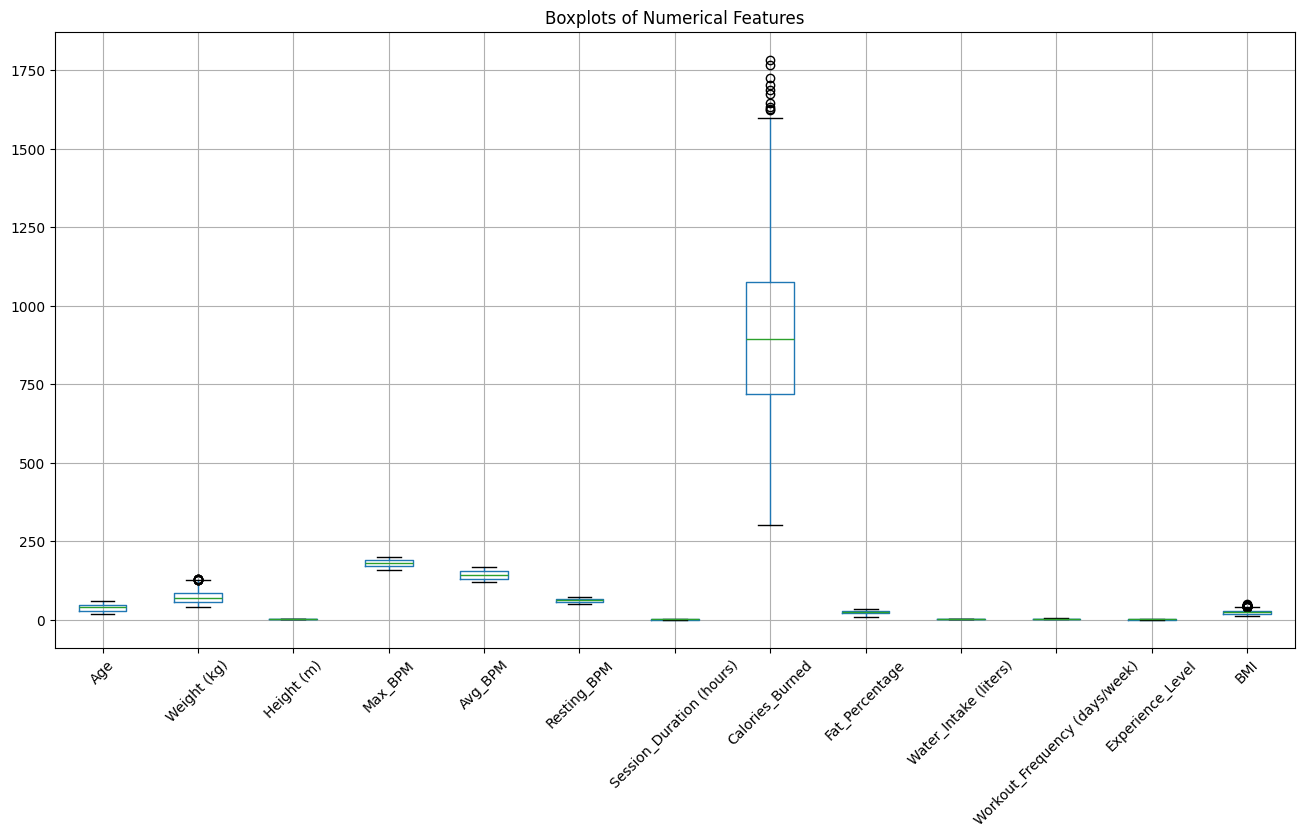

In [114]:
import matplotlib.pyplot as plt

# Display boxplots for all numerical columns
numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns

plt.figure(figsize=(16, 8))
df[numerical_columns].boxplot(rot=45)
plt.title("Boxplots of Numerical Features")
plt.show()

In [115]:
# Summarize potential outliers using the IQR method
outlier_summary = []

for column in numerical_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - (1.5 * IQR)
    upper_bound = Q3 + (1.5 * IQR)

    outlier_count = df[(df[column] < lower_bound) | (df[column] > upper_bound)].shape[0]

    outlier_summary.append({
        "Feature": column,
        "Potential Outliers": outlier_count
    })

outlier_df = pd.DataFrame(outlier_summary)
outlier_df

,Feature,Potential Outliers
0,Age,0
1,Weight (kg),9
2,Height (m),0
3,Max_BPM,0
4,Avg_BPM,0
5,Resting_BPM,0
6,Session_Duration (hours),0
7,Calories_Burned,10
8,Fat_Percentage,0
9,Water_Intake (liters),0


#### Observation

The boxplots and IQR analysis identified a small number of potential outliers in the **Weight (kg)**, **Calories_Burned**, and **BMI** variables, while no potential outliers were detected in the remaining numerical features. These observations represent extreme values based on the statistical distribution of the data rather than confirmed errors.

Since the dataset contains information about individuals with different body compositions and exercise habits, these values are considered realistic and may represent genuine variations among gym members. Therefore, no outliers were removed because there was no evidence that they resulted from data entry errors or inaccurate measurements. Retaining these observations preserves the integrity of the dataset and ensures that legitimate variations are included in the subsequent analysis.

## Data Cleaning Summary

The dataset was successfully examined for common data quality issues prior to analysis. No missing values or duplicate records were identified, and all variables were stored using appropriate data types. The categorical variables were reviewed and found to have consistent formatting with no spelling or capitalization inconsistencies. Potential outliers were detected in the **Weight (kg)**, **Calories_Burned**, and **BMI** variables using the IQR method; however, these values were retained because they represent realistic variations in fitness-related measurements rather than data entry errors. Overall, the dataset was determined to be clean, consistent, and suitable for exploratory data analysis and the application of data mining techniques.

# Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) was performed to better understand the characteristics of the dataset before applying data mining techniques. Visualizations were used to examine the distribution of variables, identify potential patterns and relationships, detect outliers, and gain insights into the factors that may influence exercise performance and calories burned. The findings from this analysis will help guide feature selection and modeling in later stages of the project.

### Examining the Distribution of Numerical Variables

Understanding the distribution of numerical variables helps identify the overall shape of the data, detect skewness, and recognize unusual patterns. Histograms were created for each numerical feature to visualize how the observations are distributed across different value ranges.

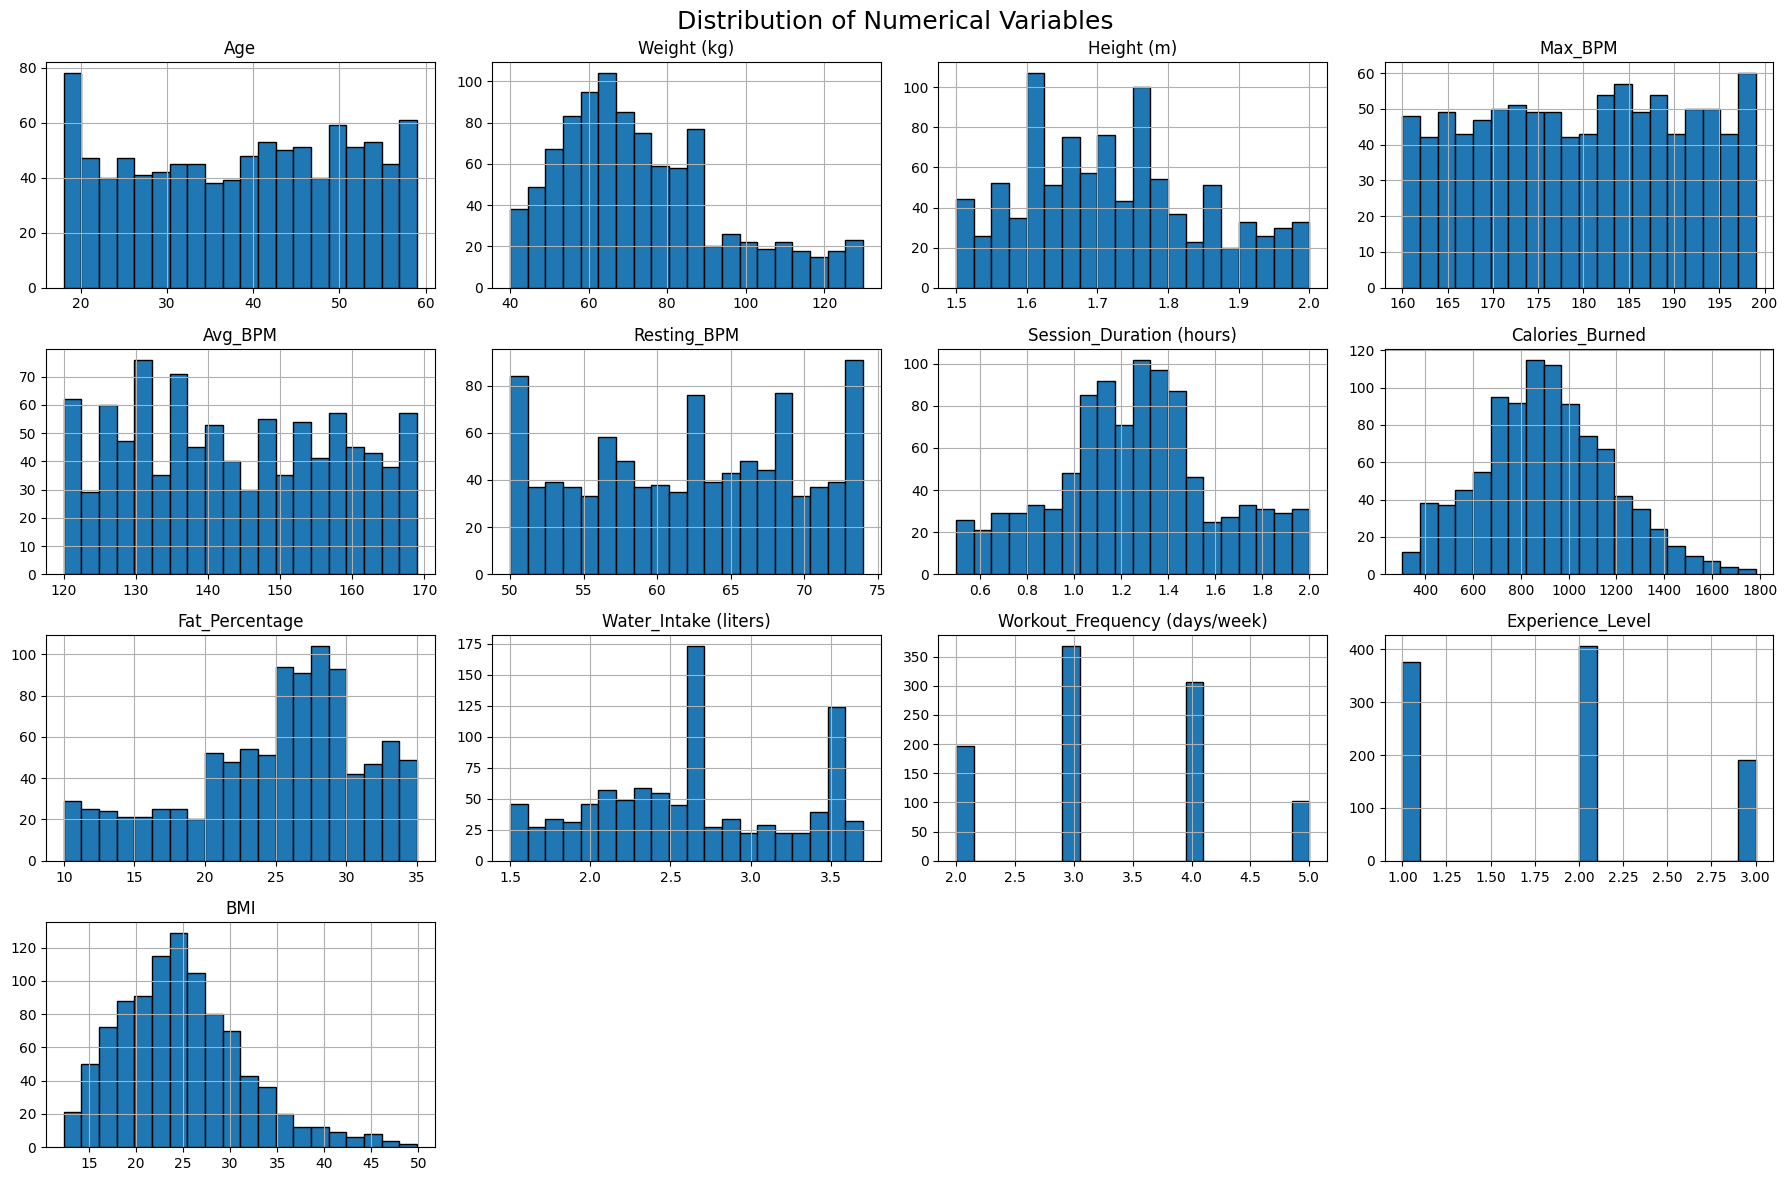

In [116]:
import matplotlib.pyplot as plt

# Plot histograms for all numerical variables
df.hist(figsize=(18, 12), bins=20, edgecolor='black')

plt.suptitle("Distribution of Numerical Variables", fontsize=18)
plt.tight_layout()
plt.show()

#### Observation

The histograms provide an overview of the distribution of the numerical variables in the dataset. Most features exhibit reasonable distributions with no unusual gaps or irregular patterns, suggesting that the dataset is well balanced.

Several variables, including **Calories_Burned**, **BMI**, **Weight (kg)**, and **Session_Duration (hours)**, display approximately bell-shaped distributions, indicating that most observations are concentrated around the center with fewer observations at the extremes. Variables such as **Workout_Frequency (days/week)** and **Experience_Level** are discrete because they represent predefined categories rather than continuous measurements.

Overall, the distributions suggest that the dataset contains a diverse range of gym members while maintaining realistic values across all features. These observations indicate that the numerical variables are suitable for further statistical analysis and predictive modeling.

### Examining Relationships Between Numerical Variables

A correlation heatmap was generated to examine the strength and direction of relationships between numerical variables. Correlation coefficients range from **-1** to **1**, where values closer to **1** indicate a strong positive relationship, values closer to **-1** indicate a strong negative relationship, and values near **0** indicate little or no linear relationship.

Understanding these relationships helps identify which features may be useful predictors during the modeling phase.

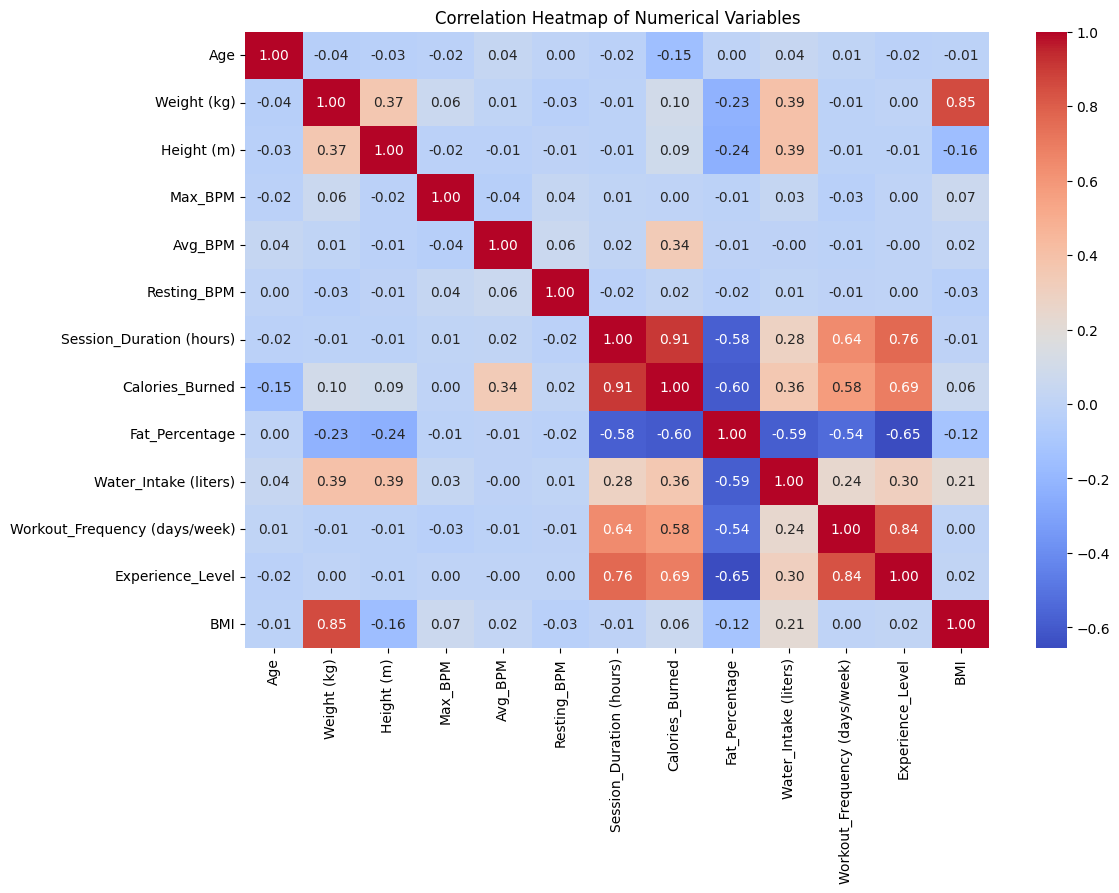

In [117]:
import seaborn as sns
import matplotlib.pyplot as plt

# Compute the correlation matrix
correlation_matrix = df.corr(numeric_only=True)

# Create the heatmap
plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap of Numerical Variables")
plt.show()

#### Observation

The correlation heatmap reveals several meaningful relationships between the numerical variables in the dataset. The strongest positive correlation is observed between **Session_Duration (hours)** and **Calories_Burned** (0.91), indicating that longer workout sessions are associated with higher calorie expenditure. This suggests that session duration is likely to be one of the most important predictors of calories burned.

Other notable positive correlations include **Workout_Frequency (days/week)** and **Experience_Level** (0.84), as well as **Weight (kg)** and **BMI** (0.85). These relationships are expected because individuals with more workout experience often exercise more frequently, and BMI is directly influenced by body weight.

Several moderate positive correlations were also observed, including **Experience_Level** and **Calories_Burned** (0.69), **Workout_Frequency** and **Calories_Burned** (0.58), and **Water_Intake (liters)** and **Calories_Burned** (0.36). These findings suggest that workout habits and hydration may also contribute to exercise performance.

The strongest negative correlations involve **Fat_Percentage**, which is negatively associated with **Calories_Burned** (-0.60), **Session_Duration** (-0.58), **Workout_Frequency** (-0.54), and **Experience_Level** (-0.65). These relationships indicate that individuals with lower body fat percentages tend to exercise more frequently, work out longer, and burn more calories.

Overall, the heatmap highlights several meaningful feature relationships that will help guide feature selection and predictive modeling in later stages of the project.

### Relationship Between Session Duration and Calories Burned

A scatter plot was created to examine the relationship between workout session duration and calories burned. Since the correlation analysis indicated a strong positive relationship between these variables, this visualization helps confirm whether longer workout sessions generally result in greater calorie expenditure.

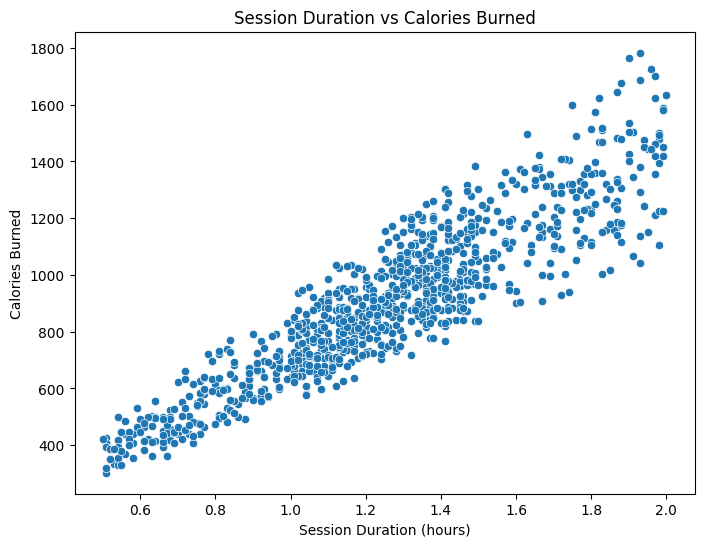

In [118]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Session_Duration (hours)",
    y="Calories_Burned"
)

plt.title("Session Duration vs Calories Burned")
plt.xlabel("Session Duration (hours)")
plt.ylabel("Calories Burned")
plt.show()

#### Observation

The scatter plot demonstrates a strong positive linear relationship between **Session_Duration (hours)** and **Calories_Burned**. As workout duration increases, the number of calories burned also increases, confirming the strong positive correlation (0.91) identified in the correlation heatmap.

Although there is some variability among individuals, the overall upward trend is consistent across the dataset. This indicates that session duration is one of the strongest predictors of calorie expenditure and is likely to play a significant role in predictive modeling.

### Calories Burned Across Workout Types

A boxplot was generated to compare the distribution of calories burned across different workout types. This visualization highlights differences in median calorie expenditure, variability, and potential outliers among the exercise categories.

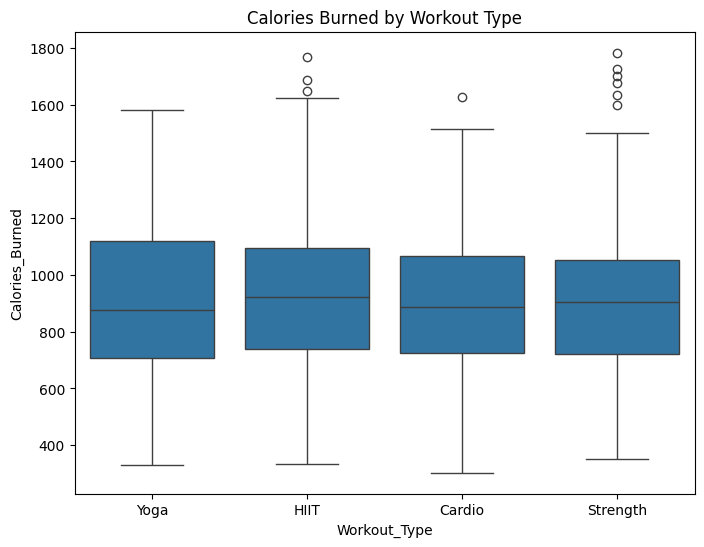

In [119]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x="Workout_Type",
    y="Calories_Burned"
)

plt.title("Calories Burned by Workout Type")
plt.show()

#### Observation

The boxplot comparing **Calories_Burned** across different workout types shows that the four exercise categories (Yoga, HIIT, Cardio, and Strength) have relatively similar distributions. While **HIIT** and **Strength** exhibit slightly higher median calorie expenditure, the differences between workout types are not substantial.

Several high-value outliers are present, particularly for **HIIT** and **Strength**, indicating that some individuals burned considerably more calories than the majority of participants. Overall, the visualization suggests that workout type may influence calories burned, but its impact appears to be less significant than workout duration.

### Calories Burned by Gender

A boxplot was used to compare the distribution of calories burned between male and female participants. This analysis helps determine whether differences in calorie expenditure exist across gender groups within the dataset.

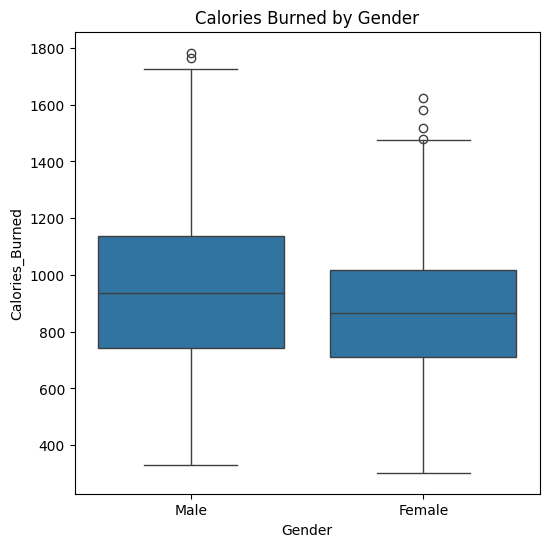

In [120]:
plt.figure(figsize=(6,6))

sns.boxplot(
    data=df,
    x="Gender",
    y="Calories_Burned"
)

plt.title("Calories Burned by Gender")
plt.show()

#### Observation

The comparison of calories burned by gender shows that male participants have a slightly higher median calorie expenditure and a wider range of values than female participants. Male participants also exhibit several higher-value outliers, indicating greater variability in calories burned during workouts.

Despite these differences, there is considerable overlap between the two groups, suggesting that gender alone is not the primary factor influencing calorie expenditure. Other variables, such as workout duration, experience level, and workout frequency, are likely to have a greater impact.

## Insights Gained from Exploratory Data Analysis

The exploratory data analysis provided several important insights into the characteristics of the dataset. The data distributions indicate that the numerical variables contain realistic values with only a small number of potential outliers. The correlation analysis revealed that **Session_Duration (hours)** has the strongest positive relationship with **Calories_Burned**, making it one of the most influential variables in the dataset. Additional positive relationships were observed between **Workout_Frequency**, **Experience_Level**, and **Calories_Burned**, while **Fat_Percentage** showed a moderate negative correlation with calorie expenditure.

The scatter plot further confirmed the strong linear relationship between workout duration and calories burned. Comparisons across workout types and gender showed some differences in calorie expenditure; however, these differences were less pronounced than the relationship observed with workout duration. Overall, the EDA suggests that exercise habits and participant characteristics together contribute to workout performance and calorie expenditure.

# **Deliverable 2: Regression Modeling and Performance Evaluation**

**Project Objective**
The purpose of this deliverable is to develop and evaluate regression models that predict an outcome variable from the Gym Members Exercise Dataset. Feature-engineering techniques will be used to improve the available predictors, and multiple regression models will be trained and evaluated.

The models will be compared using appropriate regression evaluation metrics and visualizations to determine which model provides the most accurate predictions.

### Import necessary libraries

In [121]:
# Import libraries for data manipulation
import pandas as pd
import numpy as np

# Import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Import tools for splitting and preprocessing the data
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures

# Import regression models
from sklearn.linear_model import LinearRegression, Ridge, Lasso

# Import evaluation metrics for regression models
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Display confirmation that the libraries were imported successfully
print("All required libraries were imported successfully.")

All required libraries were imported successfully.


## ***Feature Engineering***

Feature engineering is the process of creating new variables from existing dataset features. These new variables can help regression models recognize meaningful relationships that may not be immediately apparent from the original columns.

For this analysis, several features are created based on workout intensity, heart-rate behavior, body composition, hydration, and workout frequency. These engineered features may improve the model's ability to predict calories burned.

The target variable, `Calories_Burned`, is not used to create any new feature because doing so would cause data leakage.

In [122]:
# Display all column names in the dataset.
# This allows us to confirm that the required columns are available
# before creating the new engineered features.

print("Dataset columns:")
print(df.columns.tolist())

Dataset columns:
['Age', 'Gender', 'Weight (kg)', 'Height (m)', 'Max_BPM', 'Avg_BPM', 'Resting_BPM', 'Session_Duration (hours)', 'Calories_Burned', 'Workout_Type', 'Fat_Percentage', 'Water_Intake (liters)', 'Workout_Frequency (days/week)', 'Experience_Level', 'BMI']


### Create a copy of the dataset

In [123]:
# Create a copy of the original dataset before performing feature engineering.
# This protects the original DataFrame and allows us to compare the original
# features with the engineered features later.

df_engineered = df.copy()

print("A copy of the dataset was created successfully.")
print("Original number of features:", df.shape[1])

A copy of the dataset was created successfully.
Original number of features: 15


### Engineered Feature 1: Heart Rate Increase

In [124]:
# Calculate how much the participant's average heart rate increased
# above their resting heart rate during the workout.
#
# A larger value generally indicates that the workout required more
# cardiovascular effort.

df_engineered["Heart_Rate_Increase"] = (
    df_engineered["Avg_BPM"] - df_engineered["Resting_BPM"]
)

### Engineered Feature 2: Heart Rate Intensity Ratio

In [125]:
# Calculate the participant's average workout heart rate as a proportion
# of their recorded maximum heart rate.
#
# This creates a normalized intensity measurement. It can be more useful
# than Avg_BPM alone because it considers each participant's maximum BPM.

df_engineered["Heart_Rate_Intensity"] = (
    df_engineered["Avg_BPM"] / df_engineered["Max_BPM"]
)

### Engineered Feature 3: Workout Load

In [126]:
# Create a workout-load feature by combining workout intensity
# with session duration.
#
# This feature represents the total cardiovascular effort across
# the entire workout session.

df_engineered["Workout_Load"] = (
    df_engineered["Heart_Rate_Intensity"]
    * df_engineered["Session_Duration (hours)"]
)

### Engineered Feature 4: Weekly Workout Time

In [127]:
# Estimate the participant's total workout time per week.
#
# This combines the duration of an individual workout with the number
# of days the participant exercises each week.

df_engineered["Weekly_Workout_Hours"] = (
    df_engineered["Session_Duration (hours)"]
    * df_engineered["Workout_Frequency (days/week)"]
)

### Engineered Feature 5: Lean Body Mass Estimate

In [128]:
# Estimate lean body mass using the participant's weight
# and body-fat percentage.
#
# Lean body mass represents the approximate weight of the body excluding fat.

df_engineered["Lean_Body_Mass"] = (
    df_engineered["Weight (kg)"]
    * (1 - df_engineered["Fat_Percentage"] / 100)
)

### Engineered Feature 6: Fat Mass Estimate

In [129]:
# Estimate the participant's body-fat mass in kilograms.
#
# This feature complements lean body mass and provides the model
# with another measurement of body composition.

df_engineered["Fat_Mass"] = (
    df_engineered["Weight (kg)"]
    * (df_engineered["Fat_Percentage"] / 100)
)

### Engineered Feature 7: Hydration per Kilogram

In [130]:
# Normalize water intake according to the participant's body weight.
#
# Two individuals may drink the same amount of water, but that amount
# may represent different hydration levels depending on their weight.

df_engineered["Water_Per_Kg"] = (
    df_engineered["Water_Intake (liters)"]
    / df_engineered["Weight (kg)"]
)

### Engineered Feature 8: BMI Category

In [131]:
# Convert the numerical BMI feature into general BMI categories.
#
# The category provides the model with a grouped representation
# of body composition in addition to the original continuous BMI value.

df_engineered["BMI_Category"] = pd.cut(
    df_engineered["BMI"],
    bins=[0, 18.5, 25, 30, float("inf")],
    labels=[
        "Underweight",
        "Normal",
        "Overweight",
        "Obese"
    ],
    include_lowest=True
)

### Display the engineered features

In [132]:
# Create a list containing only the newly engineered feature names.
engineered_features = [
    "Heart_Rate_Increase",
    "Heart_Rate_Intensity",
    "Workout_Load",
    "Weekly_Workout_Hours",
    "Lean_Body_Mass",
    "Fat_Mass",
    "Water_Per_Kg",
    "BMI_Category"
]

# Display the first five rows of the newly created features.
# This allows us to verify that the calculations were completed correctly.

df_engineered[engineered_features].head()

,Heart_Rate_Increase,Heart_Rate_Intensity,Workout_Load,Weekly_Workout_Hours,Lean_Body_Mass,Fat_Mass,Water_Per_Kg,BMI_Category
0,97,0.872222,1.474056,6.76,77.1742,11.1258,0.039638,Obese
1,85,0.843575,1.096648,5.20,49.5089,25.3911,0.028037,Obese
2,68,0.730539,0.810898,4.44,45.3546,22.7454,0.033774,Normal
3,108,0.863158,0.509263,1.77,37.8784,15.3216,0.039474,Underweight
4,90,0.840426,0.537872,1.92,32.6388,13.4612,0.060738,Underweight


### Check for invalid values

In [133]:
# Import NumPy so that infinite values can be identified.
import numpy as np

# Check whether any engineered numerical features contain
# positive or negative infinity.
infinite_values = np.isinf(
    df_engineered[
        [
            "Heart_Rate_Intensity",
            "Workout_Load",
            "Water_Per_Kg"
        ]
    ]
).sum()

print("Infinite values in division-based features:")
print(infinite_values)


# Check whether any engineered features contain missing values.
print("\nMissing values in engineered features:")
print(df_engineered[engineered_features].isnull().sum())

Infinite values in division-based features:
Heart_Rate_Intensity    0
Workout_Load            0
Water_Per_Kg            0
dtype: int64

Missing values in engineered features:
Heart_Rate_Increase     0
Heart_Rate_Intensity    0
Workout_Load            0
Weekly_Workout_Hours    0
Lean_Body_Mass          0
Fat_Mass                0
Water_Per_Kg            0
BMI_Category            0
dtype: int64


### ***Feature Engineering Observations***

The feature-engineering process added variables that represent cardiovascular intensity, workout volume, body composition, and hydration.

- `Heart_Rate_Increase` measures the difference between average and resting heart rate.
- `Heart_Rate_Intensity` normalizes workout heart rate using the participant's maximum heart rate.
- `Workout_Load` combines workout intensity with session duration.
- `Weekly_Workout_Hours` estimates the participant's total weekly exercise volume.
- `Lean_Body_Mass` and `Fat_Mass` provide additional body-composition measurements.
- `Water_Per_Kg` normalizes water intake according to body weight.
- `BMI_Category` provides a categorical representation of the original numerical BMI feature.

These features were created without using the target variable, `Calories_Burned`, which prevents data leakage. Their usefulness will be evaluated later by comparing regression-model performance with appropriate evaluation metrics.

## ***Regression Model Development***

After completing feature engineering, the next step is to build regression models that predict the target variable, **Calories_Burned**.

Before training the models, the dataset is prepared by separating the predictor variables from the target variable. Categorical variables are converted into numerical representations using one-hot encoding so they can be used by the regression algorithms.

The dataset is then divided into training and testing sets. The training set is used to fit the regression models, while the testing set will later be used to evaluate how well the models generalize to unseen data.

Two regression models are implemented:

- Multiple Linear Regression
- Ridge Regression

The performance of these models will be evaluated and compared in the following section.

### Separate Features and Target

In [134]:
# Separate predictor variables (X) and target variable (y)

# The target variable is Calories_Burned because this is the
# value we want our regression models to predict.

y = df_engineered["Calories_Burned"]

# All remaining columns become predictor variables.
# The target variable is removed from the feature set.

X = df_engineered.drop("Calories_Burned", axis=1)

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

Feature matrix shape: (973, 22)
Target vector shape: (973,)


### Encode Categorical Variables

In [135]:
# Convert categorical variables into numerical variables

# One-hot encoding creates binary columns for each category.
# The first category is dropped to avoid multicollinearity.

X = pd.get_dummies(
    X,
    drop_first=True
)

print("Shape after one-hot encoding:", X.shape)

Shape after one-hot encoding: (973, 26)


### Train-Test Split

In [136]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets

# 80% of the data is used to train the models.
# 20% is reserved for evaluating model performance.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 778
Testing samples: 195


### Feature Scaling

In [137]:
from sklearn.preprocessing import StandardScaler

# Standardize the numerical features

# Standardization transforms each feature so that it has
# a mean of 0 and a standard deviation of 1.

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")

Feature scaling completed.


### Multiple Linerar Regression

In [138]:
from sklearn.linear_model import LinearRegression

# Build the Multiple Linear Regression model

# Create the Linear Regression model.

linear_model = LinearRegression()

# Train the model using the training data.

linear_model.fit(
    X_train_scaled,
    y_train
)

# Generate predictions on the testing data.
# These predictions will be evaluated later.

linear_predictions = linear_model.predict(
    X_test_scaled
)

print("Multiple Linear Regression model trained successfully.")

Multiple Linear Regression model trained successfully.


### Ridge Regression

In [139]:
from sklearn.linear_model import Ridge

# Build the Ridge Regression model

# Ridge Regression helps reduce overfitting by introducing
# a regularization penalty.

ridge_model = Ridge(alpha=1.0)

# Train the Ridge model.

ridge_model.fit(
    X_train_scaled,
    y_train
)

# Generate predictions for the testing data.

ridge_predictions = ridge_model.predict(
    X_test_scaled
)

print("Ridge Regression model trained successfully.")

Ridge Regression model trained successfully.


### Verify the models

In [140]:
# Display basic information about the trained models

print("Linear Regression Model")
print(linear_model)

print()

print("Ridge Regression Model")
print(ridge_model)

Linear Regression Model
LinearRegression()

Ridge Regression Model
Ridge()


## ***Model Evaluation***

The trained regression models are evaluated using the testing dataset, which contains observations that were not used during model training.

Four regression evaluation metrics are calculated:

- **R-squared (R²):** Measures the proportion of variation in calories burned that is explained by the model. A value closer to 1 indicates better performance.
- **Mean Squared Error (MSE):** Calculates the average squared difference between actual and predicted values. Lower values indicate better performance.
- **Root Mean Squared Error (RMSE):** Calculates the square root of MSE. It expresses the typical prediction error in the same unit as the target variable, calories burned.
- **Mean Absolute Error (MAE):** Calculates the average absolute difference between actual and predicted values. Lower values indicate more accurate predictions.

The same testing data is used to evaluate both models to ensure a fair comparison.

### Import Evaluation Metrics

In [141]:
# Import regression evaluation metrics

# r2_score calculates the R-squared value.
# mean_squared_error calculates the average squared prediction error.
# mean_absolute_error calculates the average absolute prediction error.

from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)

# NumPy is used to calculate the square root of MSE
# when computing RMSE.
import numpy as np

### Evaluate Multiple Linear Regression

In [142]:
# Evaluate the Multiple Linear Regression model

# Calculate R-squared.
# A value closer to 1 indicates that the model explains
# more of the variation in calories burned.
linear_r2 = r2_score(
    y_test,
    linear_predictions
)

# Calculate Mean Squared Error.
# Lower MSE values indicate smaller prediction errors.
linear_mse = mean_squared_error(
    y_test,
    linear_predictions
)

# Calculate Root Mean Squared Error.
# RMSE is expressed in the same unit as Calories_Burned.
linear_rmse = np.sqrt(linear_mse)

# Calculate Mean Absolute Error.
# MAE represents the average absolute difference between
# the actual and predicted calories burned.
linear_mae = mean_absolute_error(
    y_test,
    linear_predictions
)

print("Multiple Linear Regression Evaluation")
print("-------------------------------------")
print(f"R-squared: {linear_r2:.4f}")
print(f"Mean Squared Error: {linear_mse:.4f}")
print(f"Root Mean Squared Error: {linear_rmse:.4f}")
print(f"Mean Absolute Error: {linear_mae:.4f}")

Multiple Linear Regression Evaluation
-------------------------------------
R-squared: 0.9854
Mean Squared Error: 1215.2923
Root Mean Squared Error: 34.8610
Mean Absolute Error: 26.8968


### Evaluate Ridge Regression

In [143]:
# Evaluate the Ridge Regression model

# Calculate R-squared for the Ridge Regression predictions.
ridge_r2 = r2_score(
    y_test,
    ridge_predictions
)

# Calculate Mean Squared Error.
ridge_mse = mean_squared_error(
    y_test,
    ridge_predictions
)

# Calculate Root Mean Squared Error.
ridge_rmse = np.sqrt(ridge_mse)

# Calculate Mean Absolute Error.
ridge_mae = mean_absolute_error(
    y_test,
    ridge_predictions
)

print("Ridge Regression Evaluation")
print("---------------------------")
print(f"R-squared: {ridge_r2:.4f}")
print(f"Mean Squared Error: {ridge_mse:.4f}")
print(f"Root Mean Squared Error: {ridge_rmse:.4f}")
print(f"Mean Absolute Error: {ridge_mae:.4f}")

Ridge Regression Evaluation
---------------------------
R-squared: 0.9854
Mean Squared Error: 1214.7987
Root Mean Squared Error: 34.8540
Mean Absolute Error: 26.8977


### Create a model Comparison Table

In [144]:
# Compare evaluation metrics across both regression models

# Create a DataFrame that stores the evaluation results
# for Multiple Linear Regression and Ridge Regression.
model_results = pd.DataFrame({
    "Model": [
        "Multiple Linear Regression",
        "Ridge Regression"
    ],
    "R-squared": [
        linear_r2,
        ridge_r2
    ],
    "MSE": [
        linear_mse,
        ridge_mse
    ],
    "RMSE": [
        linear_rmse,
        ridge_rmse
    ],
    "MAE": [
        linear_mae,
        ridge_mae
    ]
})

# Round the numerical values to four decimal places
# to make the comparison table easier to read.
model_results = model_results.round(4)

# Display the completed model comparison table.
model_results

,Model,R-squared,MSE,RMSE,MAE
0,Multiple Linear Regression,0.9854,1215.2923,34.861,26.8968
1,Ridge Regression,0.9854,1214.7987,34.854,26.8977


### Identify the Best Model

In [145]:
# Identify the model with the highest R-squared value

# Locate the row containing the highest R-squared value.
best_r2_index = model_results["R-squared"].idxmax()

# Retrieve the name and R-squared value of the best model.
best_r2_model = model_results.loc[best_r2_index, "Model"]
best_r2_value = model_results.loc[best_r2_index, "R-squared"]

print("Best model based on R-squared:")
print(f"{best_r2_model} with an R-squared of {best_r2_value:.4f}")

Best model based on R-squared:
Multiple Linear Regression with an R-squared of 0.9854


In [146]:
# Identify the model with the lowest RMSE

# Lower RMSE indicates that the model's predictions are
# generally closer to the actual calories-burned values.
best_rmse_index = model_results["RMSE"].idxmin()

best_rmse_model = model_results.loc[best_rmse_index, "Model"]
best_rmse_value = model_results.loc[best_rmse_index, "RMSE"]

print("Best model based on RMSE:")
print(f"{best_rmse_model} with an RMSE of {best_rmse_value:.4f}")

Best model based on RMSE:
Ridge Regression with an RMSE of 34.8540


### Display Overall Evaluation Summary

In [147]:
# Display a concise model evaluation summary

print("MODEL PERFORMANCE SUMMARY")
print("=" * 60)

for index, row in model_results.iterrows():
    print(f"\nModel: {row['Model']}")
    print(f"R-squared: {row['R-squared']:.4f}")
    print(f"MSE:       {row['MSE']:.4f}")
    print(f"RMSE:      {row['RMSE']:.4f}")
    print(f"MAE:       {row['MAE']:.4f}")

print("\n" + "=" * 60)
print(f"Highest R-squared: {best_r2_model}")
print(f"Lowest RMSE: {best_rmse_model}")

MODEL PERFORMANCE SUMMARY

Model: Multiple Linear Regression
R-squared: 0.9854
MSE:       1215.2923
RMSE:      34.8610
MAE:       26.8968

Model: Ridge Regression
R-squared: 0.9854
MSE:       1214.7987
RMSE:      34.8540
MAE:       26.8977

Highest R-squared: Multiple Linear Regression
Lowest RMSE: Ridge Regression


### ***Model Evaluation Interpretation***

Both regression models performed very well when predicting `Calories_Burned`.

The **Multiple Linear Regression** model achieved an R-squared value of **0.9854**, while the **Ridge Regression** model also achieved an R-squared value of **0.9854**. This means that both models explained approximately **98.54% of the variation in calories burned**. The very high R-squared values indicate that the selected original and engineered features were strongly related to the target variable.

The Multiple Linear Regression model produced an MSE of **1215.2923**, an RMSE of **34.8610**, and an MAE of **26.8968**. The Ridge Regression model produced an MSE of **1214.7987**, an RMSE of **34.8540**, and an MAE of **26.8977**.

The results are extremely similar. Multiple Linear Regression had a slightly higher R-squared value before rounding and a slightly lower MAE. Ridge Regression had a slightly lower MSE and RMSE. However, these differences are very small and do not represent a meaningful difference in predictive performance.

Based on RMSE, Ridge Regression performed slightly better because its predictions had a marginally lower overall error. Ridge Regression also includes regularization, which helps control large model coefficients and may improve stability when predictors are correlated. Overall, both models demonstrated excellent performance, but Ridge Regression can be considered the preferred model because it achieved the lowest MSE and RMSE while maintaining nearly identical explanatory power.

## ***Cross-Validation***

Cross-validation is used to assess how well a model is likely to perform on unseen data.

In this analysis, 5-fold cross-validation is applied. The dataset is divided into five subsets, or folds. During each round, four folds are used for training and the remaining fold is used for validation. This process is repeated until every fold has been used as the validation set once.

The following cross-validation metrics are calculated:

- Mean R-squared
- Standard deviation of R-squared
- Mean RMSE
- Standard deviation of RMSE

Higher mean R-squared values indicate stronger predictive performance, while lower mean RMSE values indicate smaller prediction errors. A smaller standard deviation suggests that the model performs consistently across different subsets of the data.

In [148]:
# Import tools needed for cross-validation

# KFold controls how the dataset is divided into folds.
# cross_validate evaluates multiple scoring metrics during cross-validation.
# Pipeline allows preprocessing and model training to occur safely
# within each fold, which prevents data leakage.

from sklearn.model_selection import KFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge

import numpy as np
import pandas as pd

In [149]:
# Create a 5-fold cross-validation strategy

# n_splits=5 divides the dataset into five folds.
# shuffle=True randomizes the observations before creating the folds.
# random_state=42 ensures that the same folds are created
# every time the notebook is run.

cv_strategy = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print("5-fold cross-validation strategy created successfully.")

5-fold cross-validation strategy created successfully.


In [150]:
# Create regression pipelines

# The pipeline standardizes the features inside each training fold.
# This prevents information from the validation fold from influencing
# the scaling process.

linear_cv_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

ridge_cv_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=1.0))
])

print("Cross-validation pipelines created successfully.")

Cross-validation pipelines created successfully.


In [151]:
# Define the evaluation metrics used during cross-validation

# R-squared is returned normally.
# Scikit-learn returns RMSE as a negative value because its
# model-selection tools assume that larger scores are better.
# The values will be converted back to positive RMSE later.

scoring_metrics = {
    "r2": "r2",
    "rmse": "neg_root_mean_squared_error"
}

### Perform Cross Validation for Multiple Linear Regression

In [152]:
# Perform 5-fold cross-validation for Linear Regression

linear_cv_scores = cross_validate(
    estimator=linear_cv_pipeline,
    X=X,
    y=y,
    cv=cv_strategy,
    scoring=scoring_metrics,
    return_train_score=False
)

# Convert the negative RMSE values returned by scikit-learn
# into positive values so they are easier to interpret.
linear_cv_rmse = -linear_cv_scores["test_rmse"]

# Store the R-squared values from all five folds.
linear_cv_r2 = linear_cv_scores["test_r2"]

print("Multiple Linear Regression Cross-Validation Results")
print("R-squared scores:", np.round(linear_cv_r2, 4))
print("RMSE scores:", np.round(linear_cv_rmse, 4))

Multiple Linear Regression Cross-Validation Results
R-squared scores: [0.9854 0.9853 0.9838 0.9852 0.9818]
RMSE scores: [34.861  31.858  34.3284 33.9747 35.1996]


### Perform Cross Validation for Multiple Ridge Regression

In [153]:
# Perform 5-fold cross-validation for Ridge Regression

ridge_cv_scores = cross_validate(
    estimator=ridge_cv_pipeline,
    X=X,
    y=y,
    cv=cv_strategy,
    scoring=scoring_metrics,
    return_train_score=False
)

# Convert negative RMSE scores into positive values.
ridge_cv_rmse = -ridge_cv_scores["test_rmse"]

# Store the R-squared scores from all five folds.
ridge_cv_r2 = ridge_cv_scores["test_r2"]

print("Ridge Regression Cross-Validation Results")
print("R-squared scores:", np.round(ridge_cv_r2, 4))
print("RMSE scores:", np.round(ridge_cv_rmse, 4))

Ridge Regression Cross-Validation Results
R-squared scores: [0.9854 0.9853 0.9838 0.9852 0.9818]
RMSE scores: [34.854  31.8871 34.3451 34.0159 35.1865]


### Create Cross Validation Comparison Table

In [154]:
# Summarize cross-validation performance across both models

cv_results = pd.DataFrame({
    "Model": [
        "Multiple Linear Regression",
        "Ridge Regression"
    ],
    "Mean CV R-squared": [
        linear_cv_r2.mean(),
        ridge_cv_r2.mean()
    ],
    "R-squared Standard Deviation": [
        linear_cv_r2.std(),
        ridge_cv_r2.std()
    ],
    "Mean CV RMSE": [
        linear_cv_rmse.mean(),
        ridge_cv_rmse.mean()
    ],
    "RMSE Standard Deviation": [
        linear_cv_rmse.std(),
        ridge_cv_rmse.std()
    ]
})

# Round the values to four decimal places
# to make the table easier to read.
cv_results = cv_results.round(4)

# Display the cross-validation comparison table.
cv_results

,Model,Mean CV R-squared,R-squared Standard Deviation,Mean CV RMSE,RMSE Standard Deviation
0,Multiple Linear Regression,0.9843,0.0014,34.0443,1.1720
1,Ridge Regression,0.9843,0.0014,34.0577,1.1579


### Display an Overall Cross Validation Summary

In [155]:
# Display a concise cross-validation summary

print("CROSS-VALIDATION PERFORMANCE SUMMARY")
print("=" * 70)

for index, row in cv_results.iterrows():
    print(f"\nModel: {row['Model']}")
    print(f"Mean CV R-squared:             {row['Mean CV R-squared']:.4f}")
    print(f"R-squared Standard Deviation:  {row['R-squared Standard Deviation']:.4f}")
    print(f"Mean CV RMSE:                  {row['Mean CV RMSE']:.4f}")
    print(f"RMSE Standard Deviation:       {row['RMSE Standard Deviation']:.4f}")

print("\n" + "=" * 70)

CROSS-VALIDATION PERFORMANCE SUMMARY

Model: Multiple Linear Regression
Mean CV R-squared:             0.9843
R-squared Standard Deviation:  0.0014
Mean CV RMSE:                  34.0443
RMSE Standard Deviation:       1.1720

Model: Ridge Regression
Mean CV R-squared:             0.9843
R-squared Standard Deviation:  0.0014
Mean CV RMSE:                  34.0577
RMSE Standard Deviation:       1.1579



### Identify the best Cross Validation Model

In [156]:
# Identify the best-performing model based on cross-validation

# Higher mean R-squared indicates better explanatory performance.
best_cv_r2_index = cv_results["Mean CV R-squared"].idxmax()
best_cv_r2_model = cv_results.loc[best_cv_r2_index, "Model"]

# Lower mean RMSE indicates smaller average prediction errors.
best_cv_rmse_index = cv_results["Mean CV RMSE"].idxmin()
best_cv_rmse_model = cv_results.loc[best_cv_rmse_index, "Model"]

print("Best model based on mean cross-validation R-squared:")
print(best_cv_r2_model)

print("\nBest model based on mean cross-validation RMSE:")
print(best_cv_rmse_model)

Best model based on mean cross-validation R-squared:
Multiple Linear Regression

Best model based on mean cross-validation RMSE:
Multiple Linear Regression


### ***Cross-Validation Interpretation***

Five-fold cross-validation was performed to evaluate how well the regression models generalize to unseen data by repeatedly training and validating the models on different subsets of the dataset.

The **Multiple Linear Regression** model achieved a mean cross-validation **R-squared of 0.9843** with a standard deviation of **0.0014**, indicating that the model consistently explained approximately **98.43% of the variation in calories burned** across all validation folds. The model also produced a mean **RMSE of 34.0443**, showing a low average prediction error.

The **Ridge Regression** model produced nearly identical results, with a mean cross-validation **R-squared of 0.9843** and the same **R-squared standard deviation of 0.0014**. Its mean **RMSE was 34.0577**, which is only slightly higher than that of the Multiple Linear Regression model. The RMSE standard deviation of **1.1579** also indicates consistent performance across the validation folds.

Overall, both models demonstrated excellent generalization ability, as evidenced by their high mean R-squared values and low standard deviations. The cross-validation results are also very similar to the earlier test-set evaluation, suggesting that neither model is overfitting the training data.

Among the two models, **Multiple Linear Regression** performed marginally better during cross-validation because it achieved the lowest mean RMSE while maintaining the same mean R-squared as Ridge Regression. However, the performance difference between the two models is extremely small, indicating that both regression approaches are highly effective for predicting calories burned using this dataset.

# ***Visualizations***

Visualizations are used to compare the performance of the Multiple Linear Regression and Ridge Regression models and to examine the quality of their predictions.

The following visualizations are included:

1. Holdout-test R-squared comparison
2. Holdout-test RMSE comparison
3. Actual versus predicted values for Multiple Linear Regression
4. Actual versus predicted values for Ridge Regression
5. Residual distribution for Multiple Linear Regression
6. Residual distribution for Ridge Regression
7. Cross-validation R-squared comparison
8. Cross-validation RMSE comparison

Together, these visualizations show both the numerical performance of the models and the patterns in their prediction errors.

### Hold-Out Test R-Squared Comparison

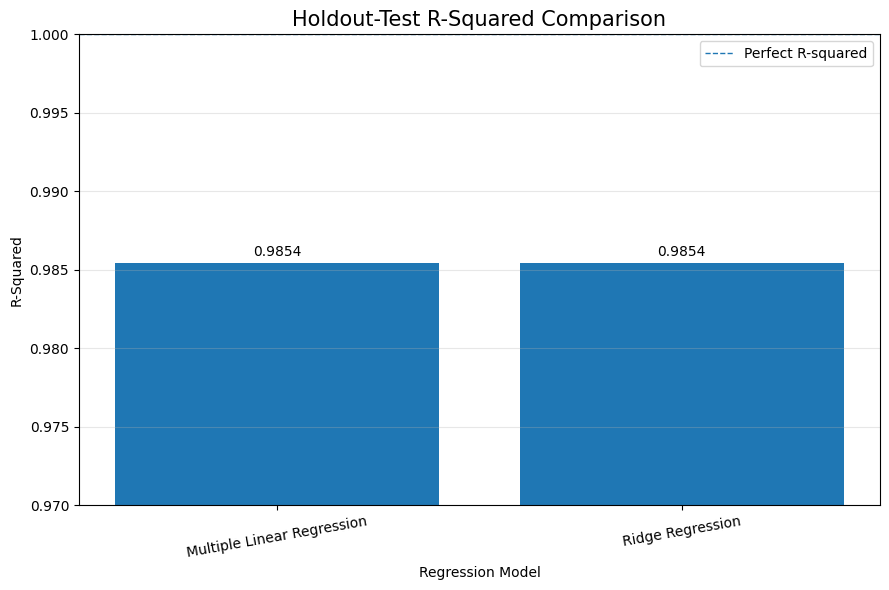

In [157]:
# Visualize the holdout-test R-squared values

import matplotlib.pyplot as plt

# Create a bar chart using the R-squared values stored
# in the model_results DataFrame.
plt.figure(figsize=(9, 6))

bars = plt.bar(
    model_results["Model"],
    model_results["R-squared"]
)

# Add a descriptive chart title and axis labels.
plt.title(
    "Holdout-Test R-Squared Comparison",
    fontsize=15
)
plt.xlabel("Regression Model")
plt.ylabel("R-Squared")

# Because both R-squared values are close to 1,
# use a focused y-axis range to make small differences visible.
plt.ylim(0.97, 1.00)

# Add a horizontal reference line at R-squared = 1,
# which represents perfect explanatory performance.
plt.axhline(
    y=1.0,
    linestyle="--",
    linewidth=1,
    label="Perfect R-squared"
)

# Display the exact R-squared value above each bar.
for bar, value in zip(bars, model_results["R-squared"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.0003,
        f"{value:.4f}",
        ha="center",
        va="bottom"
    )

# Rotate model names slightly so they remain readable.
plt.xticks(rotation=10)

# Display a light grid to make comparison easier.
plt.grid(axis="y", alpha=0.3)

plt.legend()
plt.tight_layout()
plt.show()

### R-Squared Comparison Interpretation

Both Multiple Linear Regression and Ridge Regression achieved an R-squared value of approximately **0.9854** on the testing dataset. This means that both models explained approximately **98.54% of the variation in calories burned**.

The nearly identical bar heights demonstrate that Ridge regularization did not produce a meaningful improvement in explanatory performance. Both models captured the relationship between the predictor variables and calories burned extremely well.

### Holdout-Test RMSE Comparison

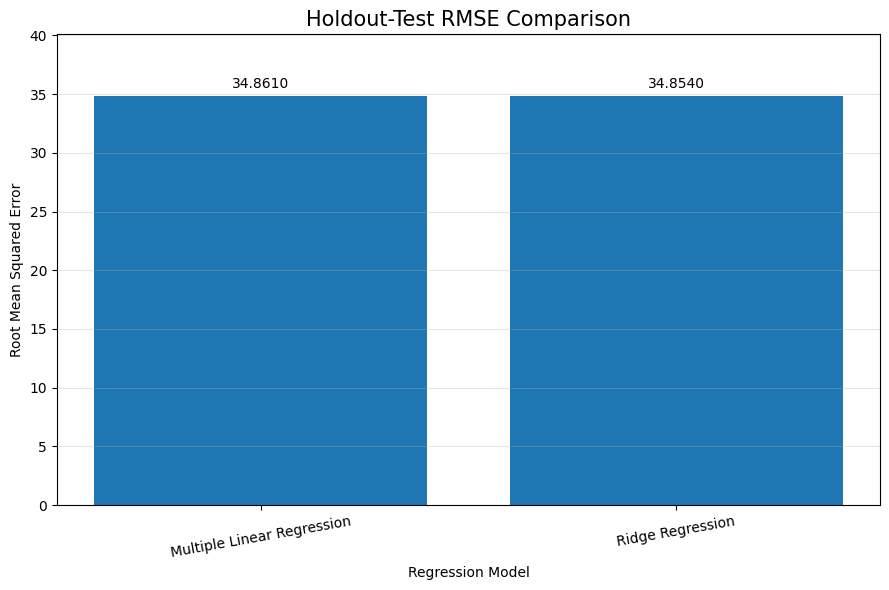

In [158]:
# Visualize the holdout-test RMSE values

plt.figure(figsize=(9, 6))

bars = plt.bar(
    model_results["Model"],
    model_results["RMSE"]
)

plt.title(
    "Holdout-Test RMSE Comparison",
    fontsize=15
)
plt.xlabel("Regression Model")
plt.ylabel("Root Mean Squared Error")

# Begin the y-axis at zero so that the bar heights
# accurately represent the size of the errors.
plt.ylim(
    0,
    model_results["RMSE"].max() * 1.15
)

# Add the exact RMSE value above each bar.
for bar, value in zip(bars, model_results["RMSE"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.4,
        f"{value:.4f}",
        ha="center",
        va="bottom"
    )

plt.xticks(rotation=10)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### Holdout-Test RMSE Interpretation

The RMSE values for the two models were nearly identical. Multiple Linear Regression achieved an RMSE of **34.8610**, while Ridge Regression achieved an RMSE of **34.8540**.

Because lower RMSE values indicate smaller prediction errors, Ridge Regression performed slightly better on the holdout testing dataset. However, the difference was only approximately **0.007 calories**, which is too small to represent a meaningful practical improvement.

The chart confirms that both models produced predictions with approximately the same level of accuracy.

### Actual vs. Predicted — Multiple Linear Regression

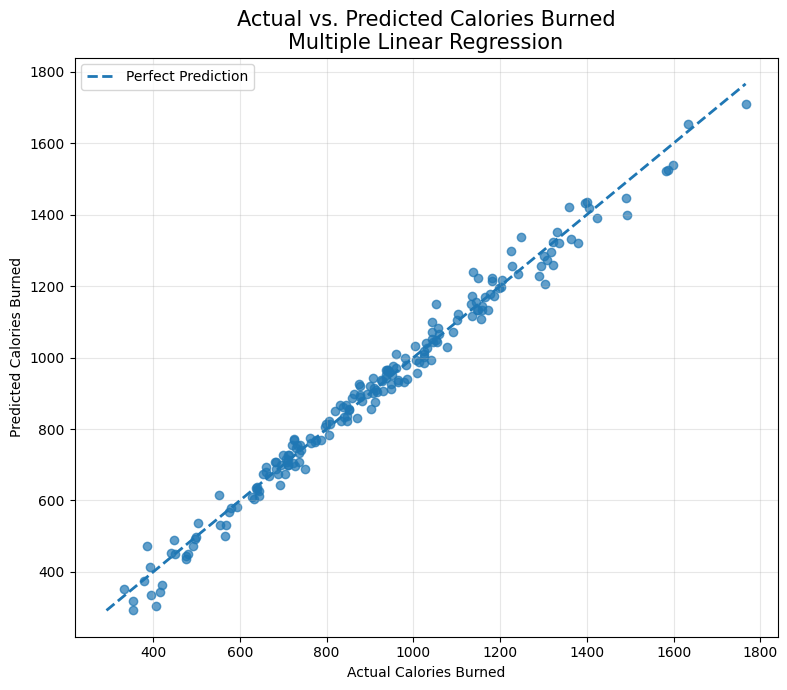

In [159]:
# Plot actual versus predicted values for Linear Regression

plt.figure(figsize=(8, 7))

# Plot each testing observation using its actual and predicted value.
plt.scatter(
    y_test,
    linear_predictions,
    alpha=0.7
)

# Determine the minimum and maximum values needed
# to draw the perfect-prediction reference line.
linear_min_value = min(
    y_test.min(),
    linear_predictions.min()
)

linear_max_value = max(
    y_test.max(),
    linear_predictions.max()
)

# Draw a diagonal reference line.
# A prediction located directly on this line is perfectly accurate.
plt.plot(
    [linear_min_value, linear_max_value],
    [linear_min_value, linear_max_value],
    linestyle="--",
    linewidth=2,
    label="Perfect Prediction"
)

plt.title(
    "Actual vs. Predicted Calories Burned\nMultiple Linear Regression",
    fontsize=15
)
plt.xlabel("Actual Calories Burned")
plt.ylabel("Predicted Calories Burned")

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### Multiple Linear Regression: Actual vs. Predicted Interpretation

The actual-versus-predicted scatter plot shows that most observations are located very close to the diagonal reference line. This indicates that the Multiple Linear Regression model generated predictions that closely matched the actual calories-burned values.

The points follow a strong linear pattern across both lower and higher calorie values. There is no obvious region in which the model consistently overpredicts or underpredicts the target. The close alignment supports the model's high R-squared value of **0.9854** and relatively low RMSE of **34.8610**.

Although some observations fall farther from the reference line, these errors are limited compared with the overall range of calories burned.

### Actual vs. Predicted — Ridge Regression

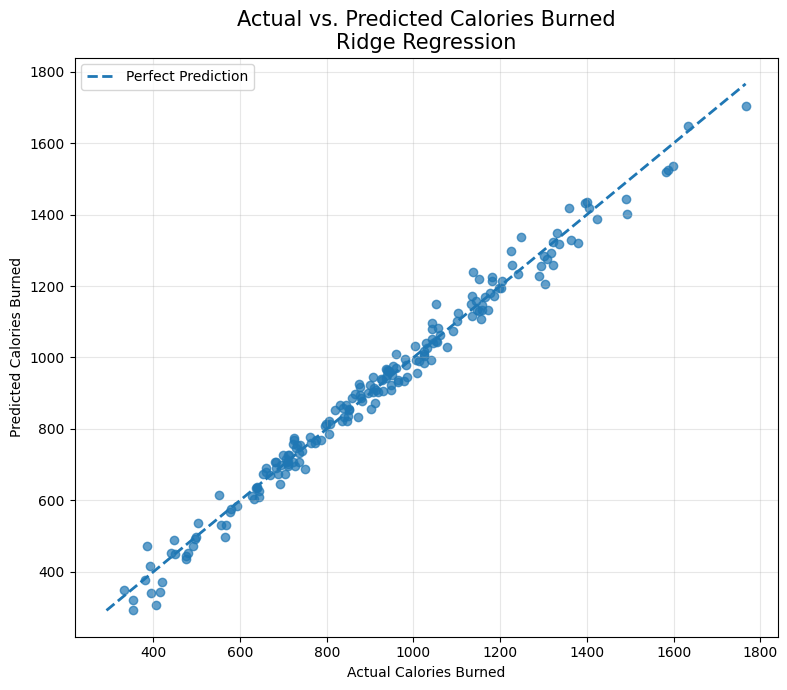

In [160]:
# Plot actual versus predicted values for Ridge Regression

plt.figure(figsize=(8, 7))

plt.scatter(
    y_test,
    ridge_predictions,
    alpha=0.7
)

# Determine the minimum and maximum values needed
# for the perfect-prediction reference line.
ridge_min_value = min(
    y_test.min(),
    ridge_predictions.min()
)

ridge_max_value = max(
    y_test.max(),
    ridge_predictions.max()
)

plt.plot(
    [ridge_min_value, ridge_max_value],
    [ridge_min_value, ridge_max_value],
    linestyle="--",
    linewidth=2,
    label="Perfect Prediction"
)

plt.title(
    "Actual vs. Predicted Calories Burned\nRidge Regression",
    fontsize=15
)
plt.xlabel("Actual Calories Burned")
plt.ylabel("Predicted Calories Burned")

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### Ridge Regression: Actual vs. Predicted Interpretation

The Ridge Regression predictions also appear close to the perfect-prediction reference line. This indicates that Ridge Regression accurately predicted calories burned across the testing dataset.

The pattern is almost identical to the Multiple Linear Regression plot, which is consistent with the nearly equal R-squared, RMSE, and MAE values produced by the two models.

Ridge Regression slightly reduced the holdout-test RMSE, but the visual difference between the two prediction plots is minimal. This suggests that regularization did not substantially change the model's predictive behavior.

### Residual Plot — Multiple Linear Regression

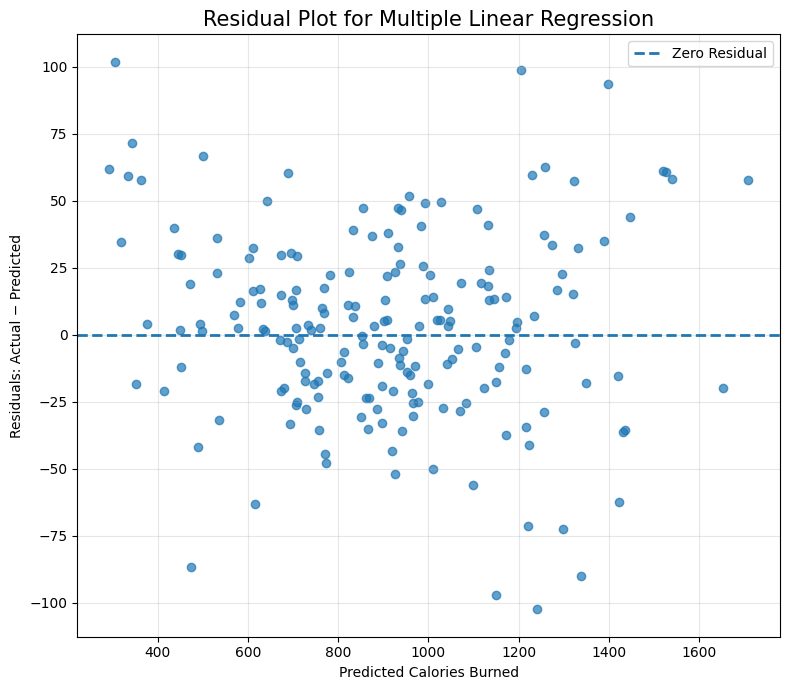

In [161]:
# Calculate and visualize Linear Regression residuals

# Calculate the difference between the actual and predicted values.
linear_residuals = y_test - linear_predictions

plt.figure(figsize=(8, 7))

# Plot predicted values against their residuals.
plt.scatter(
    linear_predictions,
    linear_residuals,
    alpha=0.7
)

# Draw a horizontal line at zero.
# Points above zero represent underprediction.
# Points below zero represent overprediction.
plt.axhline(
    y=0,
    linestyle="--",
    linewidth=2,
    label="Zero Residual"
)

plt.title(
    "Residual Plot for Multiple Linear Regression",
    fontsize=15
)
plt.xlabel("Predicted Calories Burned")
plt.ylabel("Residuals: Actual − Predicted")

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### Multiple Linear Regression Residual Interpretation

The residuals are distributed around the horizontal zero line, indicating that the model does not consistently overpredict or underpredict calories burned.

There is no strong curved pattern in the residual plot, which supports the suitability of a linear regression model for this dataset. The residual spread appears relatively consistent across the range of predicted calorie values.

A small number of observations have larger residuals, but the overall pattern appears random. This provides additional evidence that the Multiple Linear Regression model fits the data well.

### Residual Plot — Ridge Regression

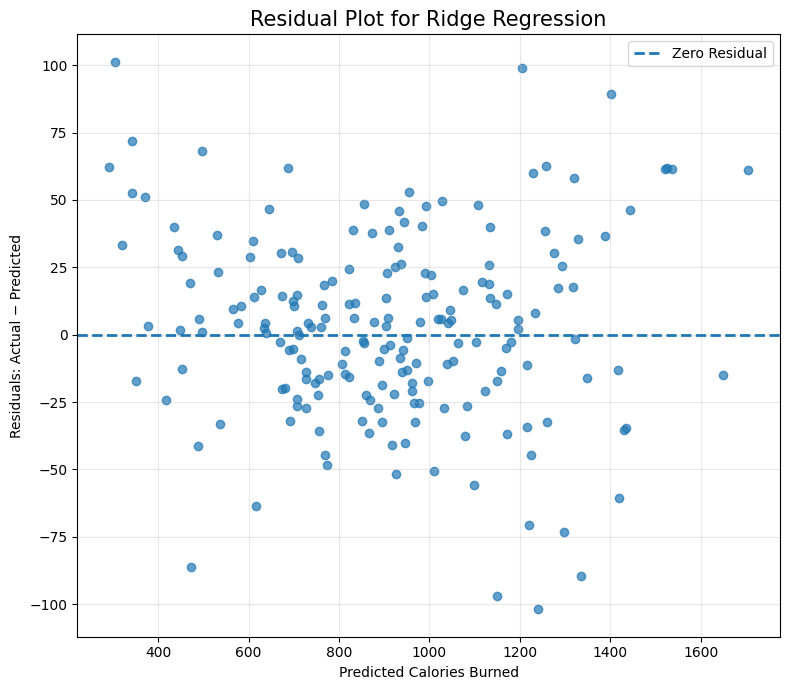

In [162]:
# Calculate and visualize Ridge Regression residuals

ridge_residuals = y_test - ridge_predictions

plt.figure(figsize=(8, 7))

plt.scatter(
    ridge_predictions,
    ridge_residuals,
    alpha=0.7
)

plt.axhline(
    y=0,
    linestyle="--",
    linewidth=2,
    label="Zero Residual"
)

plt.title(
    "Residual Plot for Ridge Regression",
    fontsize=15
)
plt.xlabel("Predicted Calories Burned")
plt.ylabel("Residuals: Actual − Predicted")

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### Ridge Regression Residual Interpretation

The Ridge Regression residuals are also centered around zero and do not display a strong systematic pattern. This indicates that Ridge Regression does not consistently predict values that are too high or too low.

The residual pattern closely resembles the pattern observed for Multiple Linear Regression. This is expected because the two models produced nearly identical evaluation results.

The absence of a clear residual pattern supports the conclusion that Ridge Regression provides an appropriate fit for predicting calories burned.

### Residual Distribution Comparison

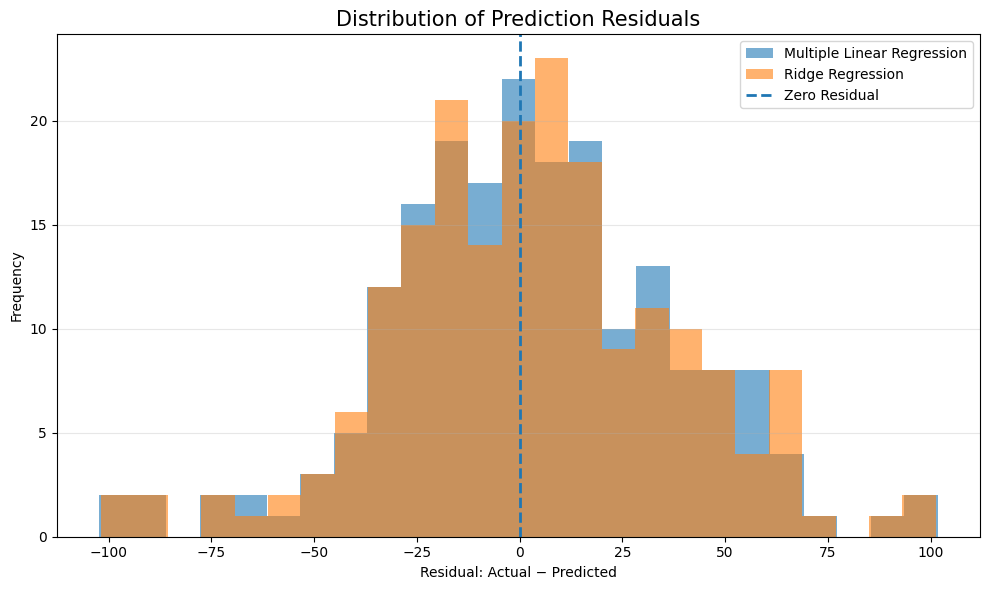

In [163]:
# Compare the distributions of residuals from both models

plt.figure(figsize=(10, 6))

# Plot the residual distribution for Multiple Linear Regression.
plt.hist(
    linear_residuals,
    bins=25,
    alpha=0.6,
    label="Multiple Linear Regression"
)

# Plot the residual distribution for Ridge Regression
# on the same axes for direct comparison.
plt.hist(
    ridge_residuals,
    bins=25,
    alpha=0.6,
    label="Ridge Regression"
)

# Add a reference line at zero residual.
plt.axvline(
    x=0,
    linestyle="--",
    linewidth=2,
    label="Zero Residual"
)

plt.title(
    "Distribution of Prediction Residuals",
    fontsize=15
)
plt.xlabel("Residual: Actual − Predicted")
plt.ylabel("Frequency")

plt.grid(axis="y", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### Residual Distribution Interpretation

The residual distributions for Multiple Linear Regression and Ridge Regression overlap almost completely. This further demonstrates that the two models produced nearly identical predictions.

Both residual distributions are centered near zero, indicating that the models do not show a strong overall tendency to overpredict or underpredict calories burned.

The similarity of the distributions supports the numerical evaluation results, which showed only very small differences between the two models.

### Mean Cross-Validation R-Squared

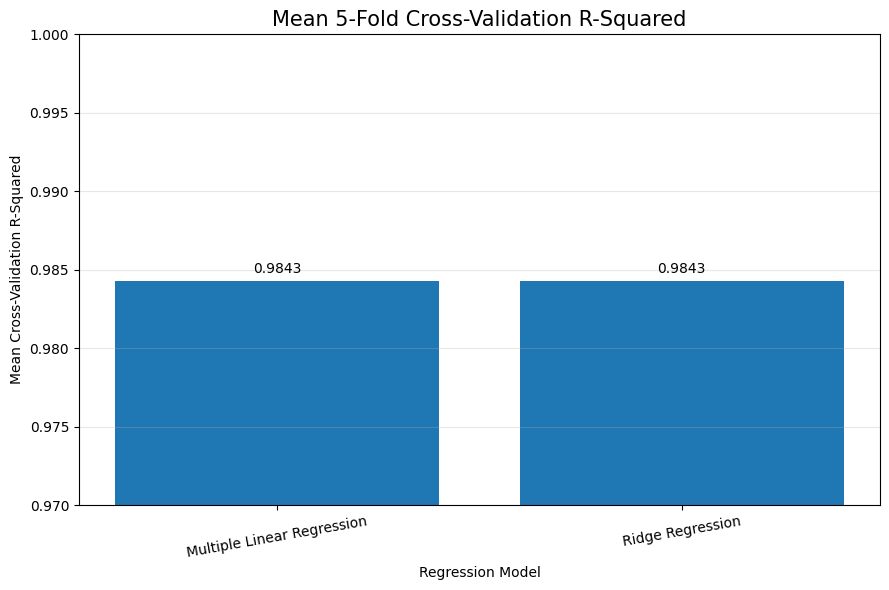

In [164]:
# Visualize mean cross-validation R-squared values

plt.figure(figsize=(9, 6))

bars = plt.bar(
    cv_results["Model"],
    cv_results["Mean CV R-squared"]
)

plt.title(
    "Mean 5-Fold Cross-Validation R-Squared",
    fontsize=15
)
plt.xlabel("Regression Model")
plt.ylabel("Mean Cross-Validation R-Squared")

# Use a focused range because both scores are close to 1.
plt.ylim(0.97, 1.00)

# Display the exact value above each bar.
for bar, value in zip(
    bars,
    cv_results["Mean CV R-squared"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.0003,
        f"{value:.4f}",
        ha="center",
        va="bottom"
    )

plt.xticks(rotation=10)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### Cross-Validation R-Squared Interpretation

Both models achieved a mean cross-validation R-squared of **0.9843**. This means that, on average, each model explained approximately **98.43% of the variation in calories burned** across the five validation folds.

The equal bar heights show that neither model had an advantage in average cross-validation explanatory performance. The strong cross-validation results also confirm that the high testing performance was not limited to one favorable train-test split.

### Mean Cross-Validation RMSE

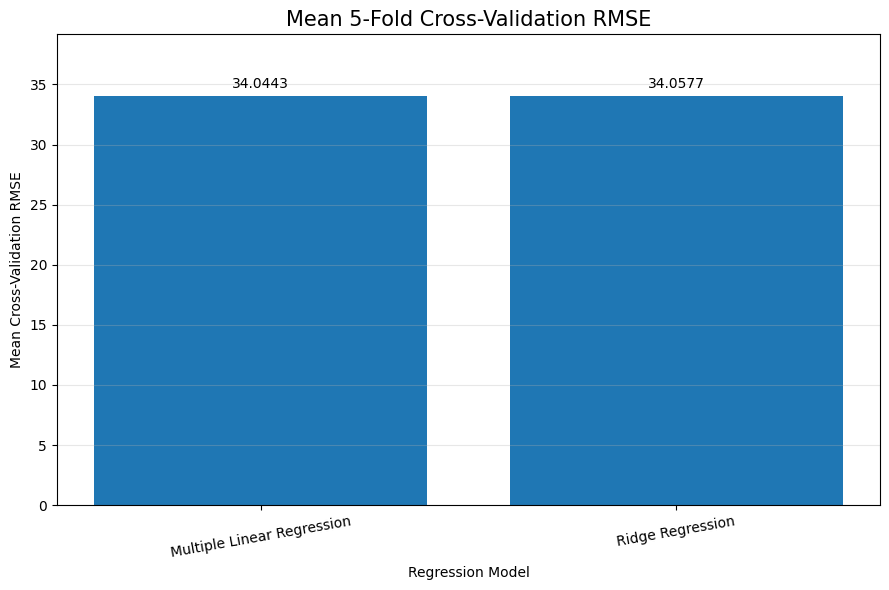

In [165]:
# Visualize mean cross-validation RMSE values

plt.figure(figsize=(9, 6))

bars = plt.bar(
    cv_results["Model"],
    cv_results["Mean CV RMSE"]
)

plt.title(
    "Mean 5-Fold Cross-Validation RMSE",
    fontsize=15
)
plt.xlabel("Regression Model")
plt.ylabel("Mean Cross-Validation RMSE")

plt.ylim(
    0,
    cv_results["Mean CV RMSE"].max() * 1.15
)

# Display the exact RMSE value above each bar.
for bar, value in zip(
    bars,
    cv_results["Mean CV RMSE"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.4,
        f"{value:.4f}",
        ha="center",
        va="bottom"
    )

plt.xticks(rotation=10)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### Cross-Validation RMSE Interpretation

Multiple Linear Regression achieved a mean cross-validation RMSE of **34.0443**, while Ridge Regression achieved a mean cross-validation RMSE of **34.0577**.

Because lower RMSE is better, Multiple Linear Regression performed marginally better across the five validation folds. However, the difference was only approximately **0.0134 calories**, which is negligible.

The visualization confirms that both models generalized to unseen data with nearly identical prediction accuracy.

### RMSE Consistency Across Cross-Validation Folds

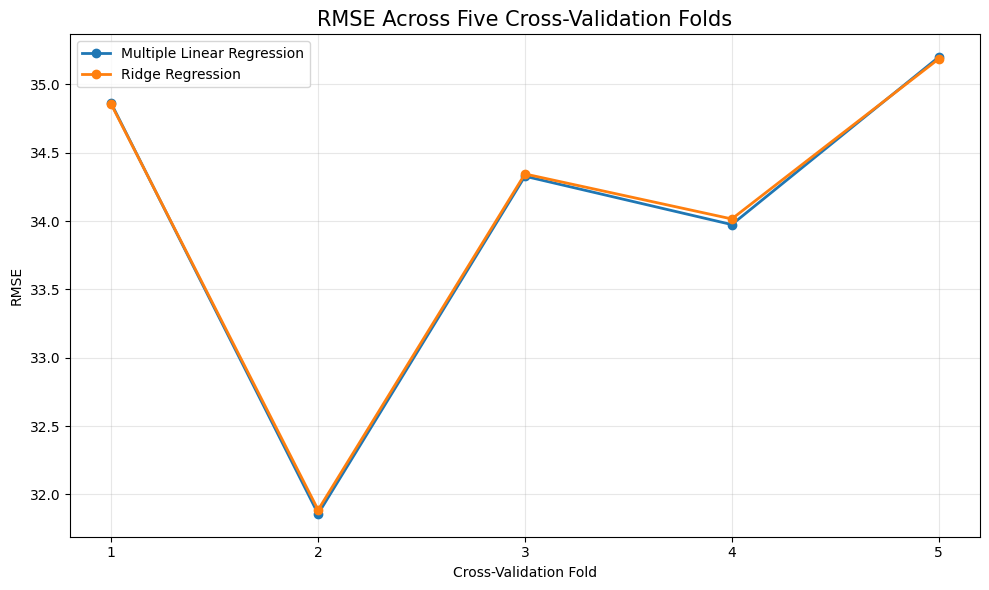

In [166]:
# Compare RMSE across all five cross-validation folds

# Create fold labels from 1 through 5.
fold_numbers = np.arange(
    1,
    len(linear_cv_rmse) + 1
)

plt.figure(figsize=(10, 6))

# Plot the RMSE from each fold for Multiple Linear Regression.
plt.plot(
    fold_numbers,
    linear_cv_rmse,
    marker="o",
    linewidth=2,
    label="Multiple Linear Regression"
)

# Plot the RMSE from each fold for Ridge Regression.
plt.plot(
    fold_numbers,
    ridge_cv_rmse,
    marker="o",
    linewidth=2,
    label="Ridge Regression"
)

plt.title(
    "RMSE Across Five Cross-Validation Folds",
    fontsize=15
)
plt.xlabel("Cross-Validation Fold")
plt.ylabel("RMSE")

# Ensure that only whole-number fold labels appear.
plt.xticks(fold_numbers)

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### RMSE Across Cross-Validation Folds Interpretation

The RMSE values for both models remain close across all five validation folds. The two lines almost completely overlap, showing that Multiple Linear Regression and Ridge Regression responded similarly to changes in the training and validation subsets.

The limited fluctuation between folds demonstrates that the models were stable and did not depend heavily on a particular subset of observations. Ridge Regression had a slightly smaller RMSE standard deviation, while Multiple Linear Regression had a slightly lower average RMSE.

Overall, this visualization supports the conclusion that both models generalize consistently to unseen data.

## ***Visualization Summary***

The model-performance visualizations support the results obtained from the numerical evaluation metrics.

The R-squared comparison showed that Multiple Linear Regression and Ridge Regression explained almost exactly the same proportion of variation in calories burned. The holdout-test RMSE comparison showed a very small advantage for Ridge Regression, while the cross-validation RMSE comparison showed a very small advantage for Multiple Linear Regression.

The actual-versus-predicted plots demonstrated that predictions from both models were closely aligned with the actual calorie values. Most observations were positioned near the perfect-prediction reference line.

The residual plots showed prediction errors distributed around zero without a strong systematic pattern. This suggests that neither model consistently overpredicted nor underpredicted calories burned. The overlapping residual distributions further demonstrated that the two models behaved almost identically.

Finally, the cross-validation visualizations showed that both models maintained strong and consistent performance across different validation folds. Overall, the visual evidence confirms that both regression models are highly accurate and generalize well to unseen observations. Multiple Linear Regression was selected as the overall model because it achieved the slightly lower average cross-validation RMSE while maintaining the same explanatory performance as Ridge Regression.

# **Final Model Evaluation Summary and Conclusion**

## Project Objective

The objective of this phase of the project was to develop regression models capable of predicting `Calories_Burned` using demographic, body-composition, heart-rate, hydration, and workout-related information from the Gym Members Exercise Dataset.

The regression modeling process included feature engineering, categorical-variable encoding, feature scaling, train-test splitting, model development, performance evaluation, and cross-validation. Two models were developed and compared:

- Multiple Linear Regression
- Ridge Regression

## Feature Engineering Summary

Several engineered features were created to provide the models with more meaningful representations of workout intensity, exercise volume, hydration, and body composition.

The newly created features included:

- `Heart_Rate_Increase`
- `Heart_Rate_Intensity`
- `Workout_Load`
- `Weekly_Workout_Hours`
- `Lean_Body_Mass`
- `Fat_Mass`
- `Water_Per_Kg`
- `BMI_Category`

For example, `Heart_Rate_Intensity` expressed average workout heart rate as a proportion of maximum heart rate, while `Workout_Load` combined workout intensity with session duration. `Weekly_Workout_Hours` represented estimated weekly exercise volume, and the body-composition features separated total body weight into estimated lean mass and fat mass.

The target variable, `Calories_Burned`, was not used to create any engineered feature. This prevented target leakage and ensured that the models were evaluated using legitimate predictor information.

## Holdout Test-Set Evaluation

The models were first evaluated using the 20% testing portion of the dataset.

The Multiple Linear Regression model achieved:

- R-squared: 0.9854
- MSE: 1215.2923
- RMSE: 34.8610
- MAE: 26.8968

The Ridge Regression model achieved:

- R-squared: 0.9854
- MSE: 1214.7987
- RMSE: 34.8540
- MAE: 26.8977

Both models explained approximately 98.54% of the variation in calories burned. This indicates an exceptionally strong relationship between the selected predictors and the target variable.

Ridge Regression produced a slightly lower MSE and RMSE on the testing dataset, while Multiple Linear Regression produced a slightly lower MAE. However, the numerical differences were extremely small. Therefore, the test-set results suggest that the two models had nearly identical predictive performance.

An RMSE of approximately 34.86 means that the models' predictions differed from the actual calorie values by roughly 35 calories on average when larger errors were given greater weight. An MAE of approximately 26.90 means that the average absolute prediction difference was about 27 calories.

## Cross-Validation Evaluation

Five-fold cross-validation was used to determine whether the strong testing performance remained consistent across different subsets of the dataset.

The Multiple Linear Regression model achieved:

- Mean cross-validation R-squared: 0.9843
- R-squared standard deviation: 0.0014
- Mean cross-validation RMSE: 34.0443
- RMSE standard deviation: 1.1720

The Ridge Regression model achieved:

- Mean cross-validation R-squared: 0.9843
- R-squared standard deviation: 0.0014
- Mean cross-validation RMSE: 34.0577
- RMSE standard deviation: 1.1579

Both models explained approximately 98.43% of the variation in calories burned across the five validation folds. The R-squared standard deviation of only 0.0014 demonstrates that model performance changed very little between folds.

The mean cross-validation RMSE values were also close to the original test-set RMSE values. This similarity provides evidence that the strong model performance was not caused by one unusually favorable train-test split.

Multiple Linear Regression achieved the slightly lower mean cross-validation RMSE. Ridge Regression achieved the slightly lower RMSE standard deviation, suggesting marginally more consistent prediction errors across the five folds. However, these differences were too small to represent a meaningful practical advantage.

## Best-Performing Model

Multiple Linear Regression was selected as the best-performing model overall.

The model achieved the same rounded test R-squared and mean cross-validation R-squared as Ridge Regression. It also produced the lowest mean cross-validation RMSE, indicating that it had the smallest average prediction error across the five validation folds.

Ridge Regression performed marginally better on the original testing split based on MSE and RMSE, but Multiple Linear Regression performed marginally better when performance was averaged across multiple folds. Because cross-validation provides a more comprehensive assessment than a single train-test split, the cross-validation result was given greater weight in the final model selection.

Nevertheless, the difference between the models was extremely small. The results indicate that both models are suitable for predicting calories burned. Ridge Regression may still be valuable when coefficient stability or multicollinearity is a concern because its regularization penalty limits large coefficient values.

## Key Insights Gained for Deliverable 2

The analysis produced several important insights.

First, calories burned could be predicted with very high accuracy using the available demographic, physiological, and workout-related variables. The high R-squared values demonstrate that the dataset contains strong predictive relationships.

Second, feature engineering provided meaningful representations of exercise behavior. Variables such as workout load, heart-rate intensity, and weekly workout hours represented combinations of existing features that may be more informative than the original variables considered independently.

Third, the nearly identical performance of Multiple Linear Regression and Ridge Regression suggests that strong linear relationships exist between the predictors and calories burned. Ridge regularization did not produce a major performance improvement, which indicates that severe overfitting was not present in the standard linear model.

Fourth, the cross-validation results demonstrated excellent model stability. The very small R-squared standard deviations show that both models performed consistently across different samples of the dataset.

Finally, the similarity between the holdout-test metrics and cross-validation metrics suggests that the models generalize well to unseen observations rather than simply memorizing the training data.


# **Project Deliverable 3: Regression Modeling and Performance Evaluation**


## Check Target Variable

In [167]:
print("Workout Type Distribution:")
print(df["Workout_Type"].value_counts())

print("\nPercentage Distribution:")
print(df["Workout_Type"].value_counts(normalize=True) * 100)

Workout Type Distribution:
Workout_Type
Strength    258
Cardio      255
Yoga        239
HIIT        221
Name: count, dtype: int64

Percentage Distribution:
Workout_Type
Strength    26.515930
Cardio      26.207605
Yoga        24.563207
HIIT        22.713258
Name: proportion, dtype: float64


### **Target Variable Distribution**

The target variable, `Workout_Type`, contains four classes: Strength, Cardio, Yoga, and HIIT. The classes are relatively evenly distributed, with Strength representing 26.52% of the dataset, Cardio 26.21%, Yoga 24.56%, and HIIT 22.71%.

Since no single class dominates the dataset, significant class imbalance is not present. Therefore, the dataset is suitable for multiclass classification without requiring additional class-balancing techniques. A stratified train-test split will be used to preserve these class proportions in both the training and testing datasets.

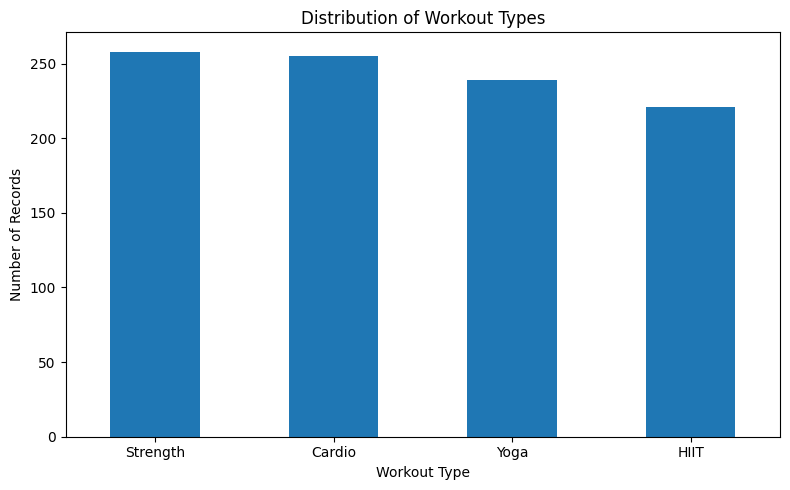

In [168]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

df["Workout_Type"].value_counts().plot(kind="bar")

plt.title("Distribution of Workout Types")
plt.xlabel("Workout Type")
plt.ylabel("Number of Records")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Preparing Features for Classification

`Workout_Type` is selected as the target variable (`y`), while the remaining variables are used as predictor features (`X`).

Because machine learning models require numerical input, the categorical `Gender` variable is converted into numerical form using one-hot encoding. The dataset is then divided into 80% training data and 20% testing data. Stratified sampling is used to maintain approximately the same distribution of workout types in both datasets.

### Prepare X and Y

In [169]:
X = df.drop(columns=["Workout_Type"])
y = df["Workout_Type"]

# Convert categorical Gender variable to numerical representation
X = pd.get_dummies(X, columns=["Gender"], drop_first=True)

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

print("\nFeatures:")
print(X.columns.tolist())

Feature matrix shape: (973, 14)
Target shape: (973,)

Features:
['Age', 'Weight (kg)', 'Height (m)', 'Max_BPM', 'Avg_BPM', 'Resting_BPM', 'Session_Duration (hours)', 'Calories_Burned', 'Fat_Percentage', 'Water_Intake (liters)', 'Workout_Frequency (days/week)', 'Experience_Level', 'BMI', 'Gender_Male']


### Train Test/Split

In [170]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())

Training set: (778, 14)
Testing set: (195, 14)

Training class distribution:
Workout_Type
Strength    206
Cardio      204
Yoga        191
HIIT        177
Name: count, dtype: int64

Testing class distribution:
Workout_Type
Strength    52
Cardio      51
Yoga        48
HIIT        44
Name: count, dtype: int64


## **Classification Model Development**

Two classification algorithms are developed to predict `Workout_Type`: a Decision Tree Classifier and a k-Nearest Neighbors (k-NN) Classifier. Using two different classification approaches allows their predictive performance to be compared on the same dataset.

### Model 1: Decision Tree Classifier

The Decision Tree algorithm classifies observations by recursively dividing the feature space based on conditions that best separate the target classes. It is useful for this dataset because it can model nonlinear relationships between gym member characteristics and workout types and does not require feature scaling.

An initial Decision Tree model is trained using default parameters to establish baseline performance before hyperparameter tuning.

In [171]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

# Create baseline Decision Tree model
dt_model = DecisionTreeClassifier(random_state=42)

# Train the model
dt_model.fit(X_train, y_train)

# Make predictions
dt_predictions = dt_model.predict(X_test)

# Calculate evaluation metrics
dt_accuracy = accuracy_score(y_test, dt_predictions)
dt_f1 = f1_score(y_test, dt_predictions, average="weighted")

print("Decision Tree Accuracy:", round(dt_accuracy, 4))
print("Decision Tree Weighted F1 Score:", round(dt_f1, 4))

print("\nClassification Report:")
print(classification_report(y_test, dt_predictions))

Decision Tree Accuracy: 0.2615
Decision Tree Weighted F1 Score: 0.2597

Classification Report:
              precision    recall  f1-score   support

      Cardio       0.25      0.25      0.25        51
        HIIT       0.23      0.27      0.25        44
    Strength       0.30      0.33      0.31        52
        Yoga       0.27      0.19      0.22        48

    accuracy                           0.26       195
   macro avg       0.26      0.26      0.26       195
weighted avg       0.26      0.26      0.26       195



#### Decision Tree Confusion Matrix

A confusion matrix is used to examine the number of correct and incorrect predictions made for each workout type. Values along the diagonal represent correctly classified observations, while off-diagonal values represent misclassifications between workout categories.

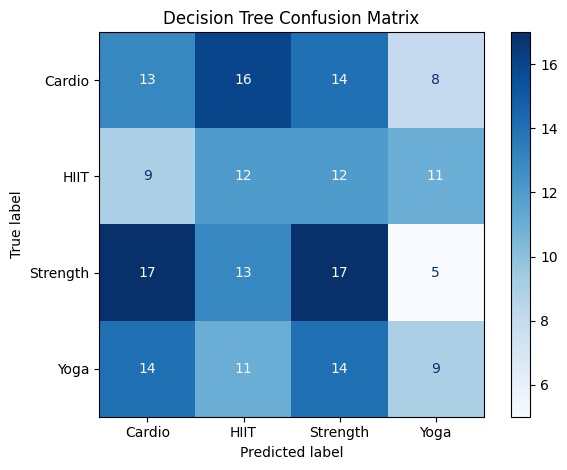

In [172]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    dt_predictions,
    cmap="Blues"
)

plt.title("Decision Tree Confusion Matrix")
plt.tight_layout()
plt.show()

#### Decision Tree ROC Curve

Since `Workout_Type` contains four classes, multiclass ROC analysis is performed using a One-vs-Rest (OvR) approach. Each workout category is treated as the positive class while the remaining categories are treated as negative.

The Area Under the Curve (AUC) measures the model's ability to distinguish each workout type from the others. An AUC closer to 1.0 indicates stronger discriminatory performance, while an AUC near 0.5 indicates performance close to random classification.

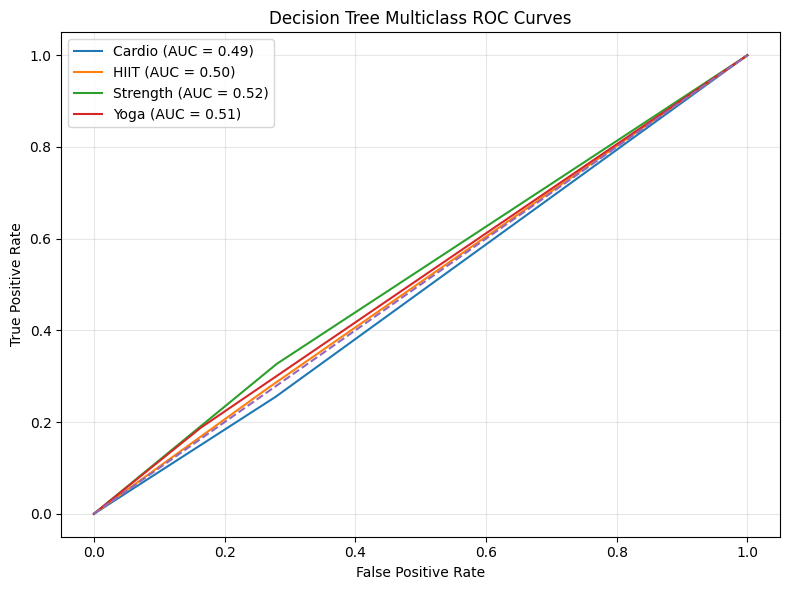

In [173]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# Get class probabilities
dt_probabilities = dt_model.predict_proba(X_test)

# Get classes in the same order used by the model
classes = dt_model.classes_

# Convert actual labels to binary format for multiclass ROC
y_test_bin = label_binarize(y_test, classes=classes)

plt.figure(figsize=(8, 6))

for i, class_name in enumerate(classes):
    fpr, tpr, _ = roc_curve(
        y_test_bin[:, i],
        dt_probabilities[:, i]
    )

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"{class_name} (AUC = {roc_auc:.2f})"
    )

# Random-classification reference line
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Decision Tree Multiclass ROC Curves")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

#### Decision Tree Results and Interpretation

The baseline Decision Tree achieved an accuracy of 26.15% and a weighted F1-score of 0.2597. Because the dataset contains four relatively balanced workout categories, this performance is only slightly better than the approximately 25% accuracy that could be expected from random classification.

The class-level results also show weak predictive performance across all four workout types. Strength had the highest F1-score at 0.31, while Yoga had the lowest at 0.22. The confusion matrix shows substantial misclassification among all four workout categories, indicating that the Decision Tree was unable to identify clear boundaries that reliably separate the workout types.

The multiclass ROC analysis supports this conclusion. The AUC values were 0.49 for Cardio, 0.50 for HIIT, 0.52 for Strength, and 0.51 for Yoga. Since an AUC near 0.50 represents discrimination close to random chance, the baseline Decision Tree has limited ability to distinguish between the workout categories.

These results suggest that the available demographic, physiological, and exercise-related features may not contain strong patterns for predicting Workout_Type, or that the default Decision Tree configuration is not appropriate for capturing those patterns. Hyperparameter tuning will later be used to determine whether controlling the complexity of the Decision Tree improves its generalization performance.

### Model 2: k-Nearest Neighbors (k-NN)

The second classification model is the k-Nearest Neighbors (k-NN) algorithm. Unlike a Decision Tree, k-NN is a distance-based algorithm that assigns a class based on the classes of nearby observations in the feature space.

Because the predictor variables are measured on substantially different scales, feature standardization is necessary before applying k-NN. For example, variables such as Calories_Burned contain much larger numerical values than variables such as Height or Session_Duration. Without scaling, features with larger numerical ranges could disproportionately influence the distance calculations.

StandardScaler is therefore fitted using the training data and then applied to both the training and testing sets. A baseline k-NN model with k=5 is used for the initial comparison.

In [174]:
from sklearn.preprocessing import StandardScaler

# Initialize the scaler
scaler = StandardScaler()

# Fit the scaler using only the training data
X_train_scaled = scaler.fit_transform(X_train)

# Apply the same transformation to the testing data
X_test_scaled = scaler.transform(X_test)

print("Training data shape:", X_train_scaled.shape)
print("Testing data shape:", X_test_scaled.shape)

Training data shape: (778, 14)
Testing data shape: (195, 14)


## Train the K-NN Model

In [175]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

# Create baseline k-NN model with k=5
knn_model = KNeighborsClassifier(n_neighbors=5)

# Train the model
knn_model.fit(X_train_scaled, y_train)

# Make predictions
knn_predictions = knn_model.predict(X_test_scaled)

# Calculate evaluation metrics
knn_accuracy = accuracy_score(y_test, knn_predictions)
knn_f1 = f1_score(y_test, knn_predictions, average="weighted")

print("k-NN Accuracy:", round(knn_accuracy, 4))
print("k-NN Weighted F1 Score:", round(knn_f1, 4))

print("\nClassification Report:")
print(classification_report(y_test, knn_predictions))

k-NN Accuracy: 0.2308
k-NN Weighted F1 Score: 0.2299

Classification Report:
              precision    recall  f1-score   support

      Cardio       0.21      0.27      0.24        51
        HIIT       0.19      0.18      0.19        44
    Strength       0.34      0.31      0.32        52
        Yoga       0.17      0.15      0.16        48

    accuracy                           0.23       195
   macro avg       0.23      0.23      0.23       195
weighted avg       0.23      0.23      0.23       195



#### k-NN Confusion Matrix

The confusion matrix is used to examine how effectively the k-NN classifier distinguishes among Cardio, HIIT, Strength, and Yoga workouts and to identify which workout categories are most frequently confused.

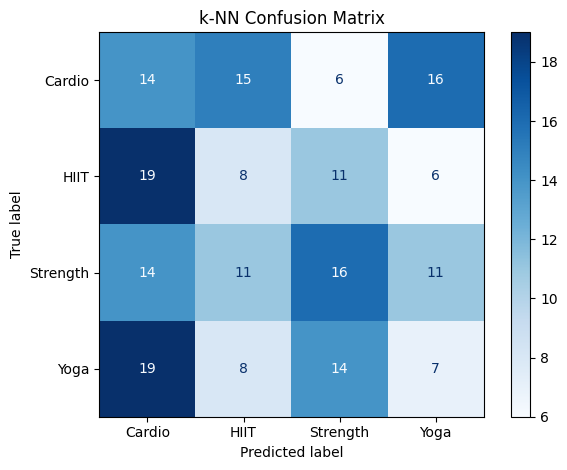

In [176]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    knn_predictions,
    cmap="Blues"
)

plt.title("k-NN Confusion Matrix")
plt.tight_layout()
plt.show()

#### k-NN ROC Curve

Multiclass ROC curves are generated using the One-vs-Rest approach. The predicted probabilities from the k-NN model are used to calculate an ROC curve and AUC value for each workout category.

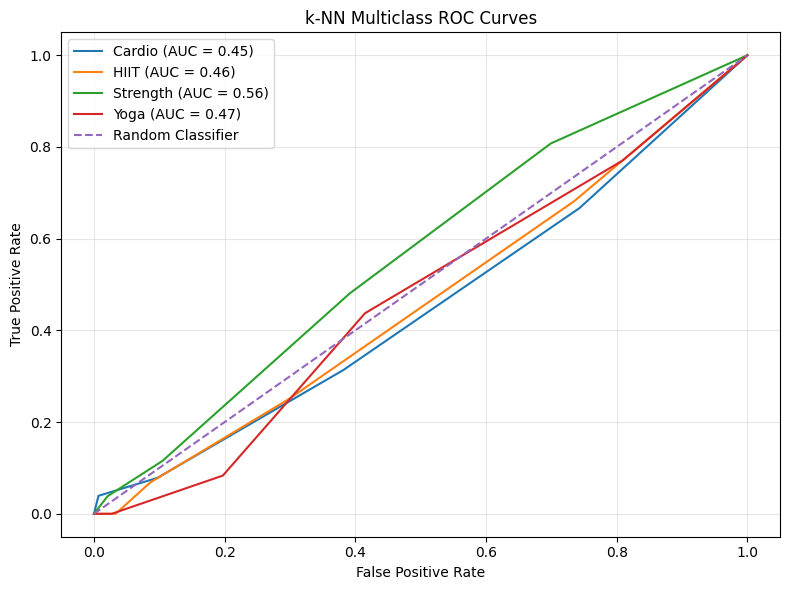

In [177]:
# Obtain predicted probabilities
knn_probabilities = knn_model.predict_proba(X_test_scaled)

# Classes in the order used by the model
knn_classes = knn_model.classes_

# Convert actual labels to binary format
y_test_bin_knn = label_binarize(
    y_test,
    classes=knn_classes
)

plt.figure(figsize=(8, 6))

for i, class_name in enumerate(knn_classes):

    fpr, tpr, _ = roc_curve(
        y_test_bin_knn[:, i],
        knn_probabilities[:, i]
    )

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"{class_name} (AUC = {roc_auc:.2f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("k-NN Multiclass ROC Curves")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

#### k-NN Results and Interpretation

The baseline k-NN classifier achieved an accuracy of 23.08% and a weighted F1-score of 0.2299. This performance is lower than the baseline Decision Tree and is also below the approximately 25% accuracy expected from random guessing across four relatively balanced classes.

The classification report shows that Strength was predicted most effectively, with an F1-score of 0.32. In contrast, Yoga had the lowest F1-score at 0.16. The confusion matrix shows substantial overlap among all four workout categories, particularly with many HIIT and Yoga observations being incorrectly classified as Cardio.

The ROC results further demonstrate the limited predictive ability of the model. The AUC values were 0.45 for Cardio, 0.46 for HIIT, 0.56 for Strength, and 0.47 for Yoga. Most values are close to 0.50, indicating weak discrimination between workout types.

Overall, k-NN did not improve classification performance compared with the Decision Tree. This suggests that the workout categories are not strongly separated within the current feature space based on Euclidean distance.

### Comparison of Baseline Classification Models

The baseline Decision Tree and k-NN models are compared using accuracy and weighted F1-score. Accuracy measures the overall proportion of correct predictions, while the weighted F1-score accounts for both precision and recall across all classes while considering their relative frequencies.

In [178]:
comparison_df = pd.DataFrame({
    "Model": ["Decision Tree", "k-NN"],
    "Accuracy": [dt_accuracy, knn_accuracy],
    "Weighted F1 Score": [dt_f1, knn_f1]
})

comparison_df

,Model,Accuracy,Weighted F1 Score
0,Decision Tree,0.261538,0.259676
1,k-NN,0.230769,0.229926


## Model Comparison Visualization

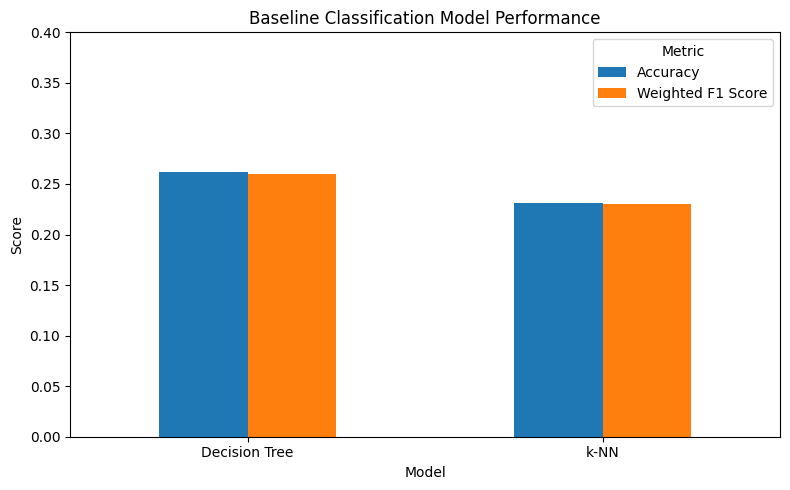

In [179]:
comparison_plot = comparison_df.set_index("Model")

comparison_plot.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Baseline Classification Model Performance")
plt.ylabel("Score")
plt.xlabel("Model")
plt.ylim(0, 0.4)
plt.xticks(rotation=0)
plt.legend(title="Metric")
plt.tight_layout()

plt.show()

#### Baseline Model Comparison

The Decision Tree performed slightly better than k-NN on both evaluation metrics. The Decision Tree achieved 26.15% accuracy and a weighted F1-score of 0.2597, compared with 23.08% accuracy and a weighted F1-score of 0.2299 for k-NN.

However, neither model demonstrated strong predictive performance. Because the four target classes are relatively balanced, an accuracy near 25% represents approximately chance-level classification. Therefore, the small advantage of the Decision Tree should not be interpreted as strong predictive ability.

The results from both models suggest that the available features provide limited separation among the four workout categories. The Decision Tree is selected for hyperparameter tuning because it produced the stronger baseline performance and provides several parameters that can be adjusted to control model complexity and potentially improve generalization.

## **Hyperparameter Tuning**

Hyperparameter tuning is performed on the Decision Tree classifier to determine whether controlling the structure and complexity of the tree can improve its generalization performance.

GridSearchCV is used to systematically evaluate multiple combinations of Decision Tree hyperparameters using 5-fold cross-validation. Weighted F1-score is used as the scoring metric because it considers both precision and recall across all workout categories.

The following hyperparameters are evaluated:

- `criterion`: Determines the function used to measure the quality of a split.
- `max_depth`: Controls the maximum depth of the tree and helps prevent excessive model complexity.
- `min_samples_split`: Specifies the minimum number of observations required to split an internal node.
- `min_samples_leaf`: Specifies the minimum number of observations required in a leaf node.

The best parameter combination is selected based only on cross-validation performance on the training data. The held-out testing set remains untouched during tuning and is used afterward for final evaluation.

## Grid Search CV

In [180]:
from sklearn.model_selection import GridSearchCV

# Define the Decision Tree model
dt_grid_model = DecisionTreeClassifier(random_state=42)

# Define hyperparameter search space
param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 5, 10]
}

# Perform 5-fold cross-validation
grid_search = GridSearchCV(
    estimator=dt_grid_model,
    param_grid=param_grid,
    cv=5,
    scoring="f1_weighted",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation Weighted F1 Score:")
print(round(grid_search.best_score_, 4))

Best Parameters:
{'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 5}

Best Cross-Validation Weighted F1 Score:
0.2646


### Best Hyperparameters Identified

GridSearchCV evaluated multiple combinations of Decision Tree hyperparameters using 5-fold cross-validation. The best parameter combination identified was:

- Criterion: Gini
- Maximum Depth: None
- Minimum Samples per Leaf: 2
- Minimum Samples Required to Split: 5

The best cross-validation weighted F1-score was 0.2646.

The selected parameters allow the tree to grow without a fixed maximum depth while requiring at least five samples to split an internal node and at least two samples in each leaf. These restrictions provide some regularization compared with the default Decision Tree by preventing splits that create extremely small leaf nodes.

The optimized model is next evaluated on the held-out testing set to determine whether the improvement observed during cross-validation generalizes to unseen data.

## Tuned Model Performance

In [181]:
# Retrieve the best model found by GridSearchCV
tuned_dt_model = grid_search.best_estimator_

# Make predictions on the untouched test set
tuned_dt_predictions = tuned_dt_model.predict(X_test)

# Calculate performance metrics
tuned_dt_accuracy = accuracy_score(
    y_test,
    tuned_dt_predictions
)

tuned_dt_f1 = f1_score(
    y_test,
    tuned_dt_predictions,
    average="weighted"
)

print("Tuned Decision Tree Accuracy:",
      round(tuned_dt_accuracy, 4))

print("Tuned Decision Tree Weighted F1 Score:",
      round(tuned_dt_f1, 4))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        tuned_dt_predictions
    )
)

Tuned Decision Tree Accuracy: 0.2103
Tuned Decision Tree Weighted F1 Score: 0.2125

Classification Report:
              precision    recall  f1-score   support

      Cardio       0.19      0.25      0.22        51
        HIIT       0.16      0.18      0.17        44
    Strength       0.22      0.21      0.22        52
        Yoga       0.35      0.19      0.24        48

    accuracy                           0.21       195
   macro avg       0.23      0.21      0.21       195
weighted avg       0.23      0.21      0.21       195



### Tuned Decision Tree Confusion Matrix

The confusion matrix below shows the classification performance of the optimized Decision Tree on the held-out testing dataset. This allows the tuned model's class-specific errors to be compared with those of the original baseline model.

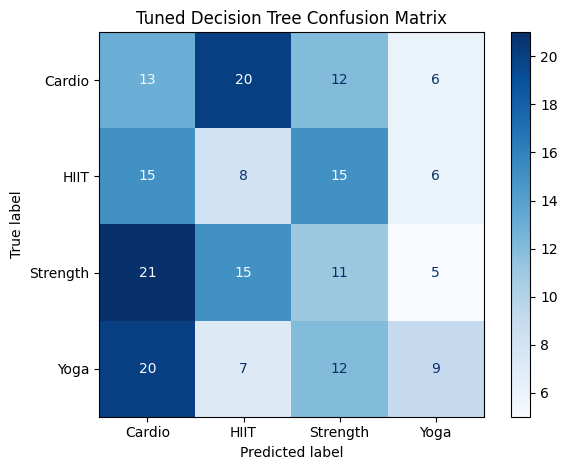

In [182]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    tuned_dt_predictions,
    cmap="Blues"
)

plt.title("Tuned Decision Tree Confusion Matrix")
plt.tight_layout()
plt.show()

## Tuned Decision Tree ROC Curves

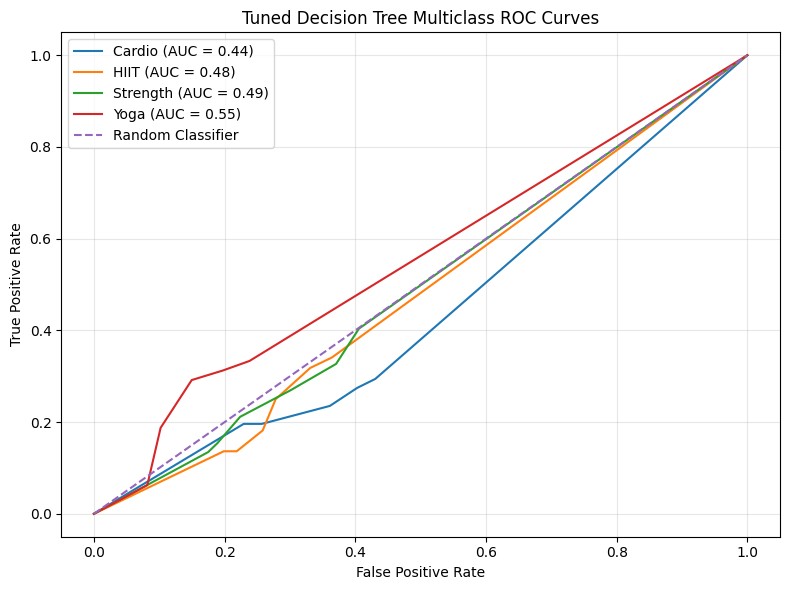

In [183]:
# Obtain predicted probabilities
tuned_dt_probabilities = tuned_dt_model.predict_proba(X_test)

tuned_classes = tuned_dt_model.classes_

# Binarize target for multiclass ROC analysis
y_test_bin_tuned = label_binarize(
    y_test,
    classes=tuned_classes
)

plt.figure(figsize=(8, 6))

for i, class_name in enumerate(tuned_classes):

    fpr, tpr, _ = roc_curve(
        y_test_bin_tuned[:, i],
        tuned_dt_probabilities[:, i]
    )

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"{class_name} (AUC = {roc_auc:.2f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Tuned Decision Tree Multiclass ROC Curves")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

## Baseline Vs Tuned Decision Tree

In [184]:
tuning_comparison = pd.DataFrame({
    "Model": [
        "Baseline Decision Tree",
        "Tuned Decision Tree"
    ],
    "Accuracy": [
        dt_accuracy,
        tuned_dt_accuracy
    ],
    "Weighted F1 Score": [
        dt_f1,
        tuned_dt_f1
    ]
})

tuning_comparison

,Model,Accuracy,Weighted F1 Score
0,Baseline Decision Tree,0.261538,0.259676
1,Tuned Decision Tree,0.210256,0.212465


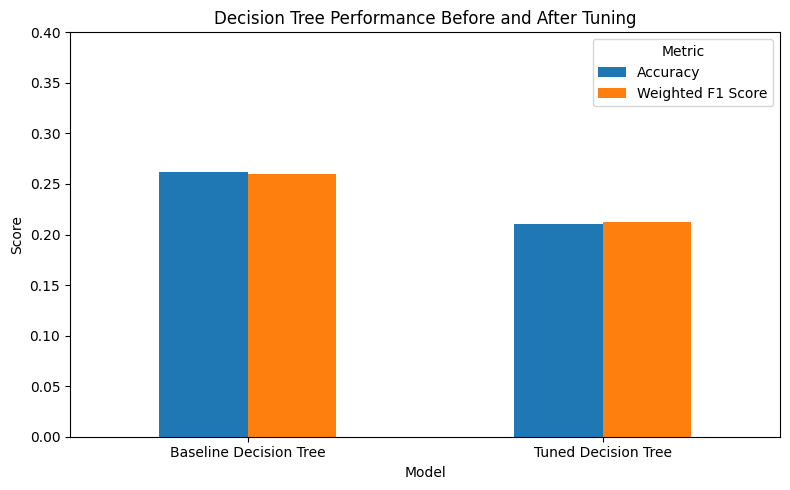

In [185]:
tuning_comparison.set_index("Model").plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Decision Tree Performance Before and After Tuning")
plt.ylabel("Score")
plt.xlabel("Model")
plt.ylim(0, 0.4)
plt.xticks(rotation=0)
plt.legend(title="Metric")
plt.tight_layout()

plt.show()

### Hyperparameter Tuning Results and Interpretation

GridSearchCV identified `criterion='gini'`, `max_depth=None`, `min_samples_leaf=2`, and `min_samples_split=5` as the best combination of Decision Tree hyperparameters. The best weighted F1-score obtained during 5-fold cross-validation was 0.2646.

However, evaluation on the held-out test set showed that hyperparameter tuning did not improve generalization performance. The tuned Decision Tree achieved an accuracy of 21.03% and a weighted F1-score of 0.2125, compared with 26.15% accuracy and a weighted F1-score of 0.2597 for the baseline Decision Tree.

The confusion matrix shows that the tuned model continued to misclassify observations across all four workout categories. The ROC analysis also demonstrated weak discrimination, with AUC values of 0.44 for Cardio, 0.48 for HIIT, 0.49 for Strength, and 0.55 for Yoga.

Although the selected hyperparameters produced the strongest average performance during cross-validation, this improvement did not transfer to the held-out test set. This highlights an important limitation of hyperparameter optimization: selecting parameters based on cross-validation does not guarantee improved performance on unseen data.

Overall, the classification results suggest that the available predictors provide limited information for distinguishing among the four workout types. The baseline Decision Tree remained the strongest of the evaluated classification models, although its performance was still close to chance level.

## **Clustering Model Development**

### K-Means Clustering

K-Means clustering is applied to identify naturally occurring groups of gym members based on their demographic, physiological, and exercise-related characteristics.

Unlike classification, clustering is an unsupervised learning technique and does not use a predefined target variable. Therefore, `Workout_Type` is excluded from the features used to construct the clusters.

Because K-Means relies on Euclidean distance, numerical features are standardized before clustering. Standardization prevents variables with larger numerical scales, such as Calories_Burned, from dominating variables measured on smaller scales, such as Height or Session_Duration.

The appropriate number of clusters is investigated using both the Elbow Method and Silhouette Score before constructing the final K-Means model.

## Prepare Clustering Data

In [186]:
from sklearn.preprocessing import StandardScaler

# Remove target variable
cluster_data = df.drop(columns=["Workout_Type"])

# Encode categorical Gender variable
cluster_data = pd.get_dummies(
    cluster_data,
    columns=["Gender"],
    drop_first=True
)

# Standardize features
cluster_scaler = StandardScaler()
cluster_scaled = cluster_scaler.fit_transform(cluster_data)

print("Clustering dataset shape:", cluster_scaled.shape)
print("Features used for clustering:")
print(cluster_data.columns.tolist())

Clustering dataset shape: (973, 14)
Features used for clustering:
['Age', 'Weight (kg)', 'Height (m)', 'Max_BPM', 'Avg_BPM', 'Resting_BPM', 'Session_Duration (hours)', 'Calories_Burned', 'Fat_Percentage', 'Water_Intake (liters)', 'Workout_Frequency (days/week)', 'Experience_Level', 'BMI', 'Gender_Male']


### Selecting the Number of Clusters

The number of clusters is not assumed in advance. Two methods are used to evaluate possible values of k from 2 through 10.

The Elbow Method examines within-cluster sum of squares (inertia). Lower inertia indicates more compact clusters, although inertia naturally decreases as additional clusters are created. The goal is to identify a point where adding more clusters produces diminishing improvements.

The Silhouette Score evaluates both cluster cohesion and separation. Values closer to 1 indicate more clearly separated clusters, values near 0 indicate overlapping clusters, and negative values may indicate inappropriate cluster assignments.

In [187]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

k_values = range(2, 11)

inertias = []
silhouette_scores = []

for k in k_values:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(cluster_scaled)

    inertias.append(kmeans.inertia_)
    silhouette_scores.append(
        silhouette_score(cluster_scaled, labels)
    )

results_k = pd.DataFrame({
    "Number of Clusters (k)": list(k_values),
    "Inertia": inertias,
    "Silhouette Score": silhouette_scores
})

results_k

,Number of Clusters (k),Inertia,Silhouette Score
0,2,10856.115742,0.230999
1,3,8987.223066,0.205450
2,4,8176.680452,0.192860
3,5,7685.446888,0.184112
4,6,7279.207973,0.157857
5,7,6997.146973,0.154613
6,8,6773.373469,0.144345
7,9,6593.020385,0.138740
8,10,6451.923479,0.137190


## Elbow method visualization

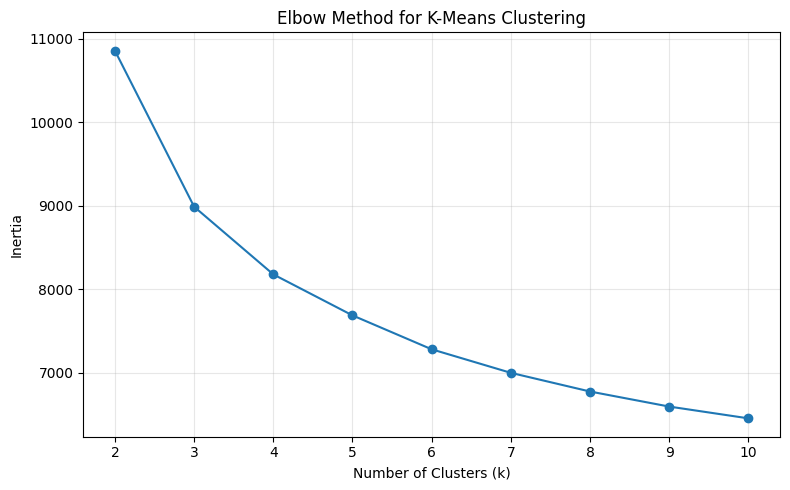

In [188]:
plt.figure(figsize=(8, 5))

plt.plot(
    list(k_values),
    inertias,
    marker="o"
)

plt.title("Elbow Method for K-Means Clustering")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.xticks(list(k_values))
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

## Silhouette Score Visualization

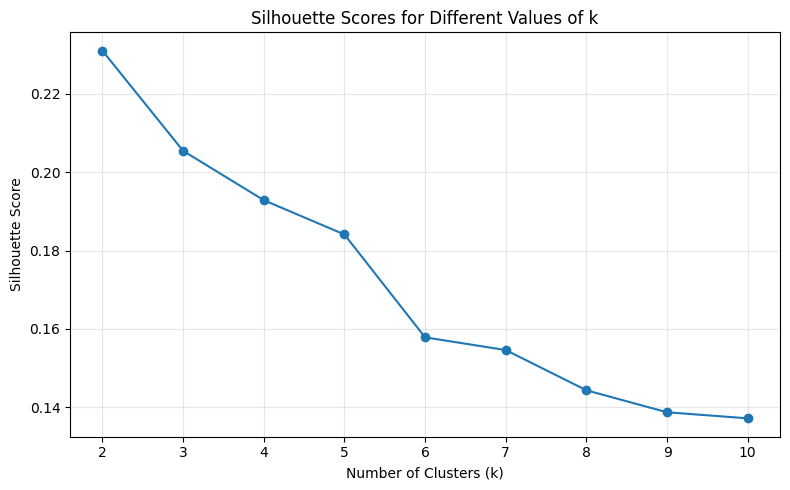

In [189]:
plt.figure(figsize=(8, 5))

plt.plot(
    list(k_values),
    silhouette_scores,
    marker="o"
)

plt.title("Silhouette Scores for Different Values of k")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.xticks(list(k_values))
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

### Selection of the Optimal Number of Clusters

The Elbow Method and Silhouette Score were evaluated for values of k ranging from 2 to 10.

The inertia decreased as the number of clusters increased, as expected. The largest reductions occurred at the lower values of k, while the improvement became progressively smaller as additional clusters were introduced. However, the elbow was not sharply defined.

The Silhouette Score provided clearer evidence for selecting the number of clusters. The highest Silhouette Score was 0.2310 at k=2, and the score consistently decreased as additional clusters were added. Therefore, two clusters were selected for the final K-Means model.

Although k=2 produced the strongest result among the evaluated values, the Silhouette Score of 0.2310 is relatively low. This indicates that the clusters have considerable overlap and should be interpreted as broad member profiles rather than strongly separated groups.

### Final K-Means Model

Based on the Elbow Method and Silhouette Score analysis, the final K-Means model is constructed using two clusters. Each gym member is assigned to one of the two clusters based on similarity across the standardized demographic, physiological, and exercise-related features.

In [190]:
# Build final K-Means model with k=2
final_kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

# Assign each observation to a cluster
cluster_labels = final_kmeans.fit_predict(cluster_scaled)

# Add cluster labels to a copy of the original dataset
clustered_df = df.copy()
clustered_df["Cluster"] = cluster_labels

print("Final Silhouette Score:",
      round(silhouette_score(cluster_scaled, cluster_labels), 4))

print("\nNumber of members in each cluster:")
print(clustered_df["Cluster"].value_counts().sort_index())

Final Silhouette Score: 0.231

Number of members in each cluster:
Cluster
0    198
1    775
Name: count, dtype: int64


### PCA Visualization of K-Means Clusters

Because the K-Means model uses 14 predictor dimensions, the complete cluster structure cannot be directly visualized in two dimensions. Principal Component Analysis (PCA) is therefore used to project the standardized feature space onto two principal components.

PCA reduces the dimensionality of the dataset while retaining as much variation as possible. The resulting two-dimensional representation is used only for visualization; the K-Means cluster assignments were generated using the complete standardized feature set.

In [191]:
from sklearn.decomposition import PCA

# Reduce standardized data to two principal components
pca = PCA(n_components=2)

cluster_pca = pca.fit_transform(cluster_scaled)

# Create DataFrame for visualization
pca_df = pd.DataFrame({
    "Principal Component 1": cluster_pca[:, 0],
    "Principal Component 2": cluster_pca[:, 1],
    "Cluster": cluster_labels
})

print(
    "Variance explained by PC1:",
    round(pca.explained_variance_ratio_[0], 4)
)

print(
    "Variance explained by PC2:",
    round(pca.explained_variance_ratio_[1], 4)
)

print(
    "Total variance explained:",
    round(pca.explained_variance_ratio_.sum(), 4)
)

Variance explained by PC1: 0.2942
Variance explained by PC2: 0.1875
Total variance explained: 0.4816


## PCA Scatter Plot

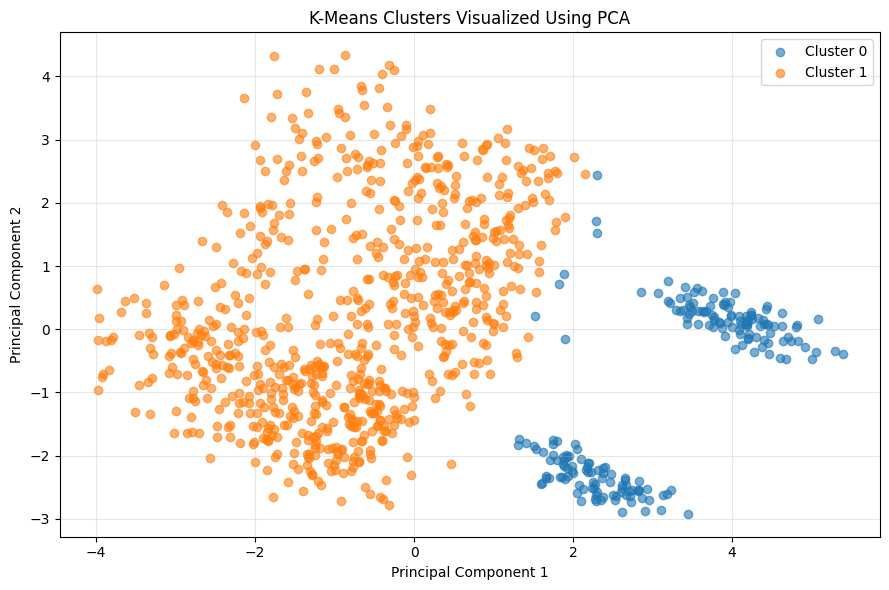

In [192]:
plt.figure(figsize=(9, 6))

for cluster in sorted(pca_df["Cluster"].unique()):

    cluster_points = pca_df[
        pca_df["Cluster"] == cluster
    ]

    plt.scatter(
        cluster_points["Principal Component 1"],
        cluster_points["Principal Component 2"],
        label=f"Cluster {cluster}",
        alpha=0.6
    )

plt.title("K-Means Clusters Visualized Using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

### Cluster Profile Analysis

To understand the characteristics represented by each cluster, the mean values of the numerical variables are calculated for each group. Comparing these profiles helps identify the demographic, physiological, and exercise-related characteristics that distinguish the two clusters.

In [193]:
# Calculate mean numerical characteristics for each cluster
cluster_profiles = clustered_df.groupby("Cluster").mean(
    numeric_only=True
).round(2)

cluster_profiles.T

Cluster,0,1
Age,37.94,38.87
Weight (kg),74.21,73.76
Height (m),1.73,1.72
Max_BPM,180.21,179.80
Avg_BPM,143.79,143.76
Resting_BPM,62.54,62.14
Session_Duration (hours),1.75,1.13
Calories_Burned,1263.47,813.95
Fat_Percentage,15.05,27.51
Water_Intake (liters),3.12,2.50


In [194]:
gender_distribution = pd.crosstab(
    clustered_df["Cluster"],
    clustered_df["Gender"],
    normalize="index"
) * 100

print("Gender Distribution Within Each Cluster (%):")
display(gender_distribution.round(2))

Gender Distribution Within Each Cluster (%):


Gender,Female,Male
Cluster,,
0,45.45,54.55
1,48.00,52.00


In [195]:
workout_distribution = pd.crosstab(
    clustered_df["Cluster"],
    clustered_df["Workout_Type"],
    normalize="index"
) * 100

print("Workout Type Distribution Within Each Cluster (%):")
display(workout_distribution.round(2))

Workout Type Distribution Within Each Cluster (%):


Workout_Type,Cardio,HIIT,Strength,Yoga
Cluster,,,,
0,24.24,25.25,23.23,27.27
1,26.71,22.06,27.35,23.87


### Cluster Results and Interpretation

The final K-Means model produced two clusters with a Silhouette Score of 0.2310. Cluster 0 contained 198 gym members, while Cluster 1 contained 775 members. The relatively low Silhouette Score indicates that the groups are not strongly separated across the complete feature space; therefore, the clusters should be interpreted as broad member profiles rather than completely distinct populations.

Cluster 0 represents a smaller group of more experienced and highly active gym members. Members in this cluster exercised approximately 4.52 days per week, had an average experience level of 2.96, and completed longer sessions averaging 1.75 hours. They also burned substantially more calories per session (1,263.47 calories), consumed more water (3.12 liters), and had a considerably lower average body-fat percentage of 15.05%.

Cluster 1 represents the larger group of less experienced and moderately active gym members. These members exercised approximately 3.02 days per week, had an average experience level of 1.51, and completed shorter sessions averaging 1.13 hours. Their average calorie expenditure was lower at 813.95 calories per session, their average water intake was 2.50 liters, and their average body-fat percentage was substantially higher at 27.51%.

In contrast, age, weight, height, BMI, and heart-rate measurements were relatively similar between the clusters. Gender composition was also similar, with males representing 54.55% of Cluster 0 and 52.00% of Cluster 1. This indicates that these characteristics were not the primary factors distinguishing the two groups.

Workout type was also distributed relatively evenly within both clusters. Cluster 0 contained 24.24% Cardio, 25.25% HIIT, 23.23% Strength, and 27.27% Yoga, while Cluster 1 contained 26.71% Cardio, 22.06% HIIT, 27.35% Strength, and 23.87% Yoga. Since Workout_Type was not used to create the clusters, this post-hoc comparison suggests that workout category itself is not strongly associated with the two identified member profiles.

Overall, the clustering results suggest that exercise experience, workout frequency, session duration, calorie expenditure, water intake, and body-fat percentage provide more meaningful differentiation among gym members than the specific type of workout performed.

#### PCA Cluster Visualization Interpretation

The first principal component explains 29.42% of the total variance, while the second explains 18.75%. Together, the two components capture approximately 48.16% of the variation in the standardized dataset.

The PCA visualization shows noticeable separation between Cluster 0 and Cluster 1, although some observations appear closer to the boundary between the groups. Because the first two principal components retain less than half of the total dataset variance, the visualization should be interpreted as a simplified two-dimensional representation of the full 14-dimensional clustering solution rather than complete evidence of cluster separation.

### Comparison of Key Cluster Characteristics

The following visualizations compare several characteristics that most clearly differentiate the two clusters. These features help provide a practical interpretation of the member profiles identified by K-Means.

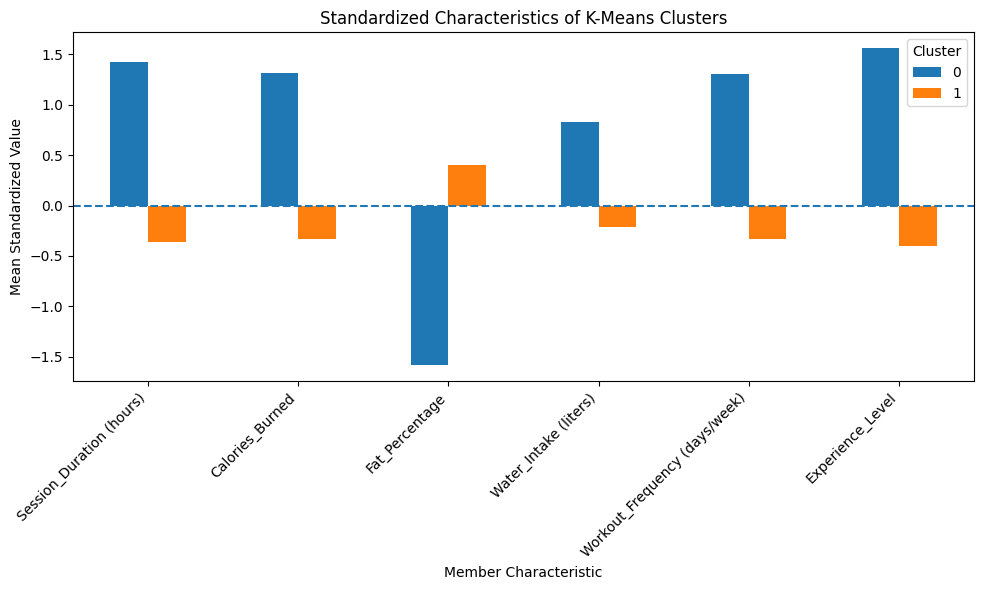

In [196]:
key_features = [
    "Session_Duration (hours)",
    "Calories_Burned",
    "Fat_Percentage",
    "Water_Intake (liters)",
    "Workout_Frequency (days/week)",
    "Experience_Level"
]

# Standardized cluster means make features with different
# measurement scales directly comparable
standardized_profiles = pd.DataFrame(
    cluster_scaled,
    columns=cluster_data.columns
)

standardized_profiles["Cluster"] = cluster_labels

standardized_key_profiles = (
    standardized_profiles
    .groupby("Cluster")[key_features]
    .mean()
    .T
)

standardized_key_profiles.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Standardized Characteristics of K-Means Clusters")
plt.xlabel("Member Characteristic")
plt.ylabel("Mean Standardized Value")
plt.axhline(0, linestyle="--")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Cluster")
plt.tight_layout()

plt.show()

#### Standardized Cluster Profile Interpretation

The standardized cluster profile highlights the characteristics that most strongly distinguish the two groups. Cluster 0 has substantially above-average session duration, calories burned, water intake, workout frequency, and experience level, while its average body-fat percentage is considerably below the dataset mean. In contrast, Cluster 1 shows below-average values for most exercise-related characteristics and a higher-than-average body-fat percentage.

These results suggest that Cluster 0 represents more experienced and highly active gym members who exercise more frequently and for longer periods, whereas Cluster 1 represents less experienced and moderately active members with shorter and less frequent workout sessions. The visualization confirms that exercise behavior and experience are major factors differentiating the two clusters.

## Association Rule Mining Using Apriori

Association rule mining is used to identify relationships and co-occurring patterns among gym member characteristics. The Apriori algorithm requires transactional or categorical data, so selected numerical variables are converted into categorical ranges before applying the algorithm.

Continuous variables such as calories burned, session duration, body-fat percentage, water intake, BMI, and workout frequency are categorized into Low, Medium, and High groups. Workout type and experience level are retained as categorical characteristics. The resulting categories are then one-hot encoded to create a transaction-style dataset suitable for Apriori.

In [197]:
# Create a separate DataFrame for association rule mining
association_df = df.copy()

# Convert continuous variables into Low, Medium, and High categories
association_df["Calories_Category"] = pd.qcut(
    association_df["Calories_Burned"],
    q=3,
    labels=["Low_Calories", "Medium_Calories", "High_Calories"]
)

association_df["Session_Category"] = pd.qcut(
    association_df["Session_Duration (hours)"],
    q=3,
    labels=["Short_Session", "Medium_Session", "Long_Session"]
)

association_df["BodyFat_Category"] = pd.qcut(
    association_df["Fat_Percentage"],
    q=3,
    labels=["Low_BodyFat", "Medium_BodyFat", "High_BodyFat"]
)

association_df["Water_Category"] = pd.qcut(
    association_df["Water_Intake (liters)"],
    q=3,
    labels=["Low_Water", "Medium_Water", "High_Water"]
)

association_df["BMI_Category"] = pd.qcut(
    association_df["BMI"],
    q=3,
    labels=["Low_BMI", "Medium_BMI", "High_BMI"]
)

association_df["Frequency_Category"] = pd.qcut(
    association_df["Workout_Frequency (days/week)"],
    q=3,
    labels=["Low_Frequency", "Medium_Frequency", "High_Frequency"],
    duplicates="drop"
)

association_df.head()

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,...,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI,Calories_Category,Session_Category,BodyFat_Category,Water_Category,BMI_Category,Frequency_Category
0,56,Male,88.3,1.71,180,157,60,1.69,1313.0,Yoga,...,3.5,4,3,30.20,High_Calories,Long_Session,Low_BodyFat,High_Water,High_BMI,Medium_Frequency
1,46,Female,74.9,1.53,179,151,66,1.30,883.0,HIIT,...,2.1,4,2,32.00,Medium_Calories,Medium_Session,High_BodyFat,Low_Water,High_BMI,Medium_Frequency
2,32,Female,68.1,1.66,167,122,54,1.11,677.0,Cardio,...,2.3,4,2,24.71,Low_Calories,Short_Session,High_BodyFat,Low_Water,Medium_BMI,Medium_Frequency
3,25,Male,53.2,1.70,190,164,56,0.59,532.0,Strength,...,2.1,3,1,18.41,Low_Calories,Short_Session,High_BodyFat,Low_Water,Low_BMI,Low_Frequency
4,38,Male,46.1,1.79,188,158,68,0.64,556.0,Strength,...,2.8,3,1,14.39,Low_Calories,Short_Session,High_BodyFat,Medium_Water,Low_BMI,Low_Frequency


### Transaction Data Preparation

For association rule mining, the selected categorical characteristics are transformed into a transaction-style binary dataset. Each row represents one gym member, while each column represents the presence or absence of a particular characteristic.

Experience level is converted into Beginner, Intermediate, and Advanced categories. Workout type is also included because it allows the analysis to investigate whether particular exercise behaviors or member characteristics are associated with Cardio, HIIT, Strength, or Yoga workouts.

One-hot encoding is then applied so that each characteristic is represented as a Boolean value, which is the format required by the Apriori algorithm.

In [198]:
# Convert experience level into meaningful categories
experience_map = {
    1: "Beginner",
    2: "Intermediate",
    3: "Advanced"
}

association_df["Experience_Category"] = (
    association_df["Experience_Level"]
    .map(experience_map)
)

# Add a prefix to workout type so rule items are easier to interpret
association_df["Workout_Category"] = (
    "Workout_" + association_df["Workout_Type"]
)

# Select categorical variables for association rule mining
transaction_columns = [
    "Workout_Category",
    "Experience_Category",
    "Calories_Category",
    "Session_Category",
    "BodyFat_Category",
    "Water_Category",
    "BMI_Category",
    "Frequency_Category"
]

transactions = association_df[transaction_columns]

transactions.head()

,Workout_Category,Experience_Category,Calories_Category,Session_Category,BodyFat_Category,Water_Category,BMI_Category,Frequency_Category
0,Workout_Yoga,Advanced,High_Calories,Long_Session,Low_BodyFat,High_Water,High_BMI,Medium_Frequency
1,Workout_HIIT,Intermediate,Medium_Calories,Medium_Session,High_BodyFat,Low_Water,High_BMI,Medium_Frequency
2,Workout_Cardio,Intermediate,Low_Calories,Short_Session,High_BodyFat,Low_Water,Medium_BMI,Medium_Frequency
3,Workout_Strength,Beginner,Low_Calories,Short_Session,High_BodyFat,Low_Water,Low_BMI,Low_Frequency
4,Workout_Strength,Beginner,Low_Calories,Short_Session,High_BodyFat,Medium_Water,Low_BMI,Low_Frequency


## One-Hot Encode the Transactions

In [199]:
# One-hot encode the categorical transaction data
transaction_encoded = pd.get_dummies(
    transactions,
    prefix="",
    prefix_sep=""
).astype(bool)

print("Transaction dataset shape:", transaction_encoded.shape)

transaction_encoded.head()

Transaction dataset shape: (973, 25)


,Workout_Cardio,Workout_HIIT,Workout_Strength,Workout_Yoga,Advanced,Beginner,Intermediate,Low_Calories,Medium_Calories,High_Calories,...,High_BodyFat,Low_Water,Medium_Water,High_Water,Low_BMI,Medium_BMI,High_BMI,Low_Frequency,Medium_Frequency,High_Frequency
0,False,False,False,True,True,False,False,False,False,True,...,False,False,False,True,False,False,True,False,True,False
1,False,True,False,False,False,False,True,False,True,False,...,True,True,False,False,False,False,True,False,True,False
2,True,False,False,False,False,False,True,True,False,False,...,True,True,False,False,False,True,False,False,True,False
3,False,False,True,False,False,True,False,True,False,False,...,True,True,False,False,True,False,False,True,False,False
4,False,False,True,False,False,True,False,True,False,False,...,True,False,True,False,True,False,False,True,False,False


In [200]:
item_support = (
    transaction_encoded
    .mean()
    .sort_values(ascending=False)
)

item_support_df = pd.DataFrame({
    "Item": item_support.index,
    "Support": item_support.values
})

item_support_df

,Item,Support
0,Low_Frequency,0.580678
1,Intermediate,0.417266
2,Beginner,0.386434
3,Low_Water,0.358684
4,Medium_Session,0.339157
5,Short_Session,0.336074
6,Low_BMI,0.335046
7,High_BMI,0.334018
8,Medium_Calories,0.334018
9,Medium_BodyFat,0.334018


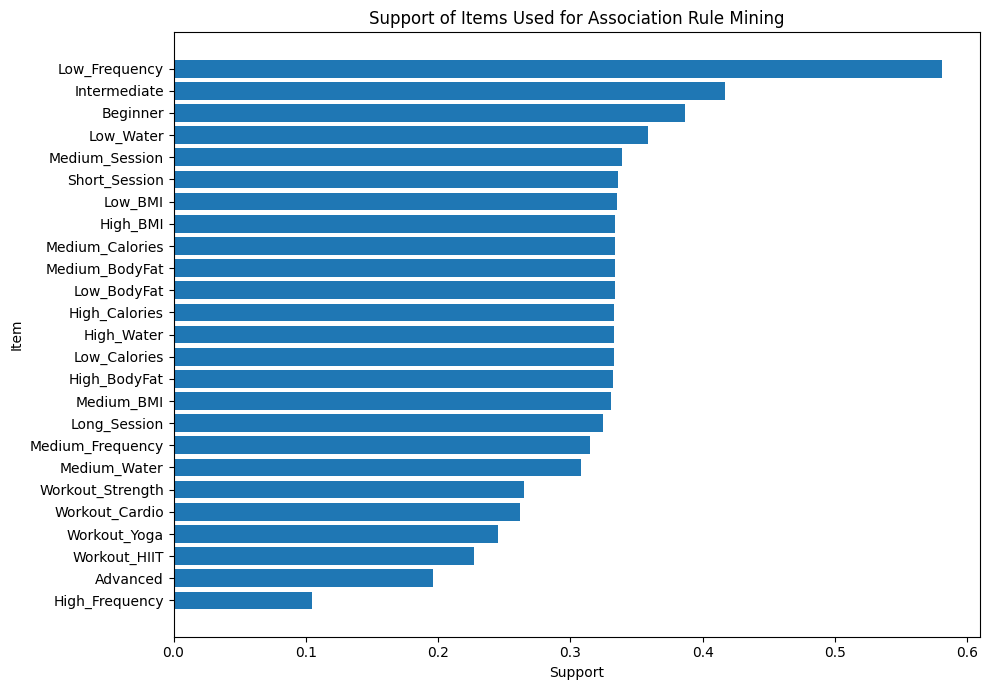

In [201]:
plt.figure(figsize=(10, 7))

plt.barh(
    item_support_df["Item"],
    item_support_df["Support"]
)

plt.xlabel("Support")
plt.ylabel("Item")
plt.title("Support of Items Used for Association Rule Mining")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Frequent Itemset Mining with Apriori

The Apriori algorithm is applied to identify combinations of gym member characteristics that frequently occur together. A minimum support threshold of 0.10 is used, meaning that an itemset must appear in at least 10% of the 973 observations to be considered frequent.

This threshold was selected after examining individual item frequencies. Several potentially informative characteristics, including high workout frequency and specific workout types, have relatively lower support. Using a substantially higher threshold could remove these patterns before association rules are generated.

In [206]:
# Install mlxtend if needed
# !pip install mlxtend

from mlxtend.frequent_patterns import apriori, association_rules

# Generate frequent itemsets
frequent_itemsets = apriori(
    transaction_encoded,
    min_support=0.10,
    use_colnames=True
)

# Add itemset length for easier analysis
frequent_itemsets["length"] = frequent_itemsets["itemsets"].apply(len)

# Sort by support
frequent_itemsets = frequent_itemsets.sort_values(
    by="support",
    ascending=False
).reset_index(drop=True)

print("Number of frequent itemsets:", len(frequent_itemsets))

frequent_itemsets.head(20)

Number of frequent itemsets: 218


,support,itemsets,length
0,0.580678,(Low_Frequency),1
1,0.417266,(Intermediate),1
2,0.386434,(Beginner),1
3,0.386434,"(Beginner, Low_Frequency)",2
4,0.358684,(Low_Water),1
5,0.339157,(Medium_Session),1
6,0.336074,(Short_Session),1
7,0.335046,(Low_BMI),1
8,0.334018,(High_BMI),1
9,0.334018,(Medium_Calories),1


### Association Rule Generation

Association rules are generated from the frequent itemsets using a minimum confidence threshold of 0.50. Confidence measures how often the consequent occurs when the antecedent is present.

The resulting rules are further filtered to retain rules with lift greater than 1.0. A lift greater than 1 indicates that the antecedent and consequent occur together more frequently than would be expected if they were independent. Support, confidence, and lift are used together to evaluate the prevalence and strength of the discovered relationships.

In [207]:
# Generate association rules
rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=0.50
)

# Keep rules showing positive association
strong_rules = rules[
    rules["lift"] > 1
].copy()

# Sort strongest rules first
strong_rules = strong_rules.sort_values(
    by=["lift", "confidence"],
    ascending=False
).reset_index(drop=True)

print("Total rules generated:", len(rules))
print("Rules with lift > 1:", len(strong_rules))

strong_rules[
    [
        "antecedents",
        "consequents",
        "support",
        "confidence",
        "lift"
    ]
].head(20)

Total rules generated: 361
Rules with lift > 1: 356


,antecedents,consequents,support,confidence,lift
0,(High_Frequency),(Advanced),0.104830,1.000000,5.094241
1,"(High_Frequency, Low_BodyFat)",(Advanced),0.104830,1.000000,5.094241
2,(High_Frequency),"(Advanced, Low_BodyFat)",0.104830,1.000000,5.094241
3,"(High_Frequency, Low_BodyFat, Long_Session)",(Advanced),0.104830,1.000000,5.094241
4,"(High_Frequency, Long_Session)","(Advanced, Low_BodyFat)",0.104830,1.000000,5.094241
5,"(High_Frequency, Low_BodyFat)","(Advanced, Long_Session)",0.104830,1.000000,5.094241
6,(High_Frequency),"(Advanced, Low_BodyFat, Long_Session)",0.104830,1.000000,5.094241
7,"(High_Frequency, Long_Session)",(Advanced),0.104830,1.000000,5.094241
8,(High_Frequency),"(Advanced, Long_Session)",0.104830,1.000000,5.094241
9,(Advanced),(High_Frequency),0.104830,0.534031,5.094241


In [208]:
# Convert frozensets into readable text
rules_display = strong_rules.copy()

rules_display["Antecedent"] = rules_display["antecedents"].apply(
    lambda x: ", ".join(sorted(list(x)))
)

rules_display["Consequent"] = rules_display["consequents"].apply(
    lambda x: ", ".join(sorted(list(x)))
)

rules_display = rules_display[
    [
        "Antecedent",
        "Consequent",
        "support",
        "confidence",
        "lift"
    ]
]

rules_display.columns = [
    "Antecedent",
    "Consequent",
    "Support",
    "Confidence",
    "Lift"
]

rules_display.head(20)

,Antecedent,Consequent,Support,Confidence,Lift
0,High_Frequency,Advanced,0.104830,1.000000,5.094241
1,"High_Frequency, Low_BodyFat",Advanced,0.104830,1.000000,5.094241
2,High_Frequency,"Advanced, Low_BodyFat",0.104830,1.000000,5.094241
3,"High_Frequency, Long_Session, Low_BodyFat",Advanced,0.104830,1.000000,5.094241
4,"High_Frequency, Long_Session","Advanced, Low_BodyFat",0.104830,1.000000,5.094241
5,"High_Frequency, Low_BodyFat","Advanced, Long_Session",0.104830,1.000000,5.094241
6,High_Frequency,"Advanced, Long_Session, Low_BodyFat",0.104830,1.000000,5.094241
7,"High_Frequency, Long_Session",Advanced,0.104830,1.000000,5.094241
8,High_Frequency,"Advanced, Long_Session",0.104830,1.000000,5.094241
9,Advanced,High_Frequency,0.104830,0.534031,5.094241


### Selection of Meaningful Association Rules

The initial Apriori results contained several redundant rules representing different combinations of the same underlying relationships. To improve interpretability, the rules were filtered to retain one-item antecedents and one-item consequents.

Rules with confidence of at least 0.50 and lift greater than 1.0 are retained. This allows the analysis to focus on concise relationships that are easier to interpret and potentially apply in a real-world fitness context.

In [209]:
# Keep simple one-to-one association rules
simple_rules = strong_rules[
    (strong_rules["antecedents"].apply(len) == 1) &
    (strong_rules["consequents"].apply(len) == 1)
].copy()

# Convert rule components to readable strings
simple_rules["Antecedent"] = simple_rules["antecedents"].apply(
    lambda x: next(iter(x))
)

simple_rules["Consequent"] = simple_rules["consequents"].apply(
    lambda x: next(iter(x))
)

# Select relevant metrics
simple_rules_display = simple_rules[
    [
        "Antecedent",
        "Consequent",
        "support",
        "confidence",
        "lift"
    ]
].copy()

simple_rules_display.columns = [
    "Antecedent",
    "Consequent",
    "Support",
    "Confidence",
    "Lift"
]

simple_rules_display = simple_rules_display.sort_values(
    by="Lift",
    ascending=False
).reset_index(drop=True)

simple_rules_display.head(15)

,Antecedent,Consequent,Support,Confidence,Lift
0,High_Frequency,Advanced,0.104830,1.000000,5.094241
1,Advanced,High_Frequency,0.104830,0.534031,5.094241
2,Advanced,Long_Session,0.196300,1.000000,3.079114
3,High_Frequency,Long_Session,0.104830,1.000000,3.079114
4,Long_Session,Advanced,0.196300,0.604430,3.079114
5,Advanced,Low_BodyFat,0.196300,1.000000,2.993846
6,High_Frequency,Low_BodyFat,0.104830,1.000000,2.993846
7,Low_BodyFat,Advanced,0.196300,0.587692,2.993846
8,Advanced,High_Calories,0.179856,0.916230,2.751519
9,High_Calories,Advanced,0.179856,0.540123,2.751519


### **Association Rule Visualization**

The following visualization compares the confidence and lift of the discovered association rules. Confidence represents the probability of observing the consequent when the antecedent occurs, while lift measures the strength of the association relative to what would be expected if the two characteristics were independent.

Rules positioned farther toward the upper-right portion of the graph represent stronger associations. Point size represents support, indicating how frequently each rule occurs within the dataset.

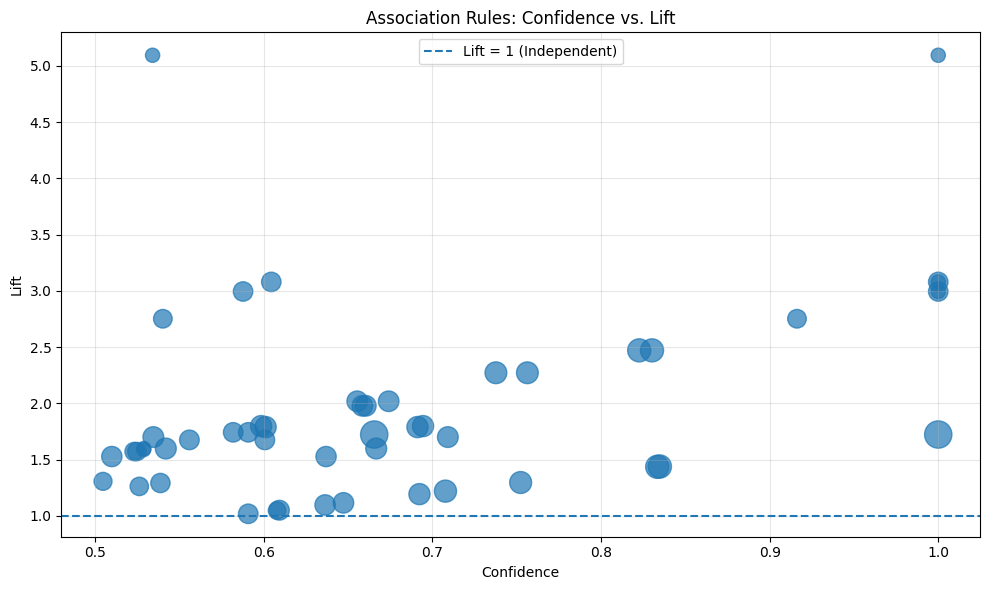

In [210]:
plt.figure(figsize=(10, 6))

plt.scatter(
    simple_rules_display["Confidence"],
    simple_rules_display["Lift"],
    s=simple_rules_display["Support"] * 1000,
    alpha=0.7
)

plt.axhline(
    y=1,
    linestyle="--",
    label="Lift = 1 (Independent)"
)

plt.xlabel("Confidence")
plt.ylabel("Lift")
plt.title("Association Rules: Confidence vs. Lift")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

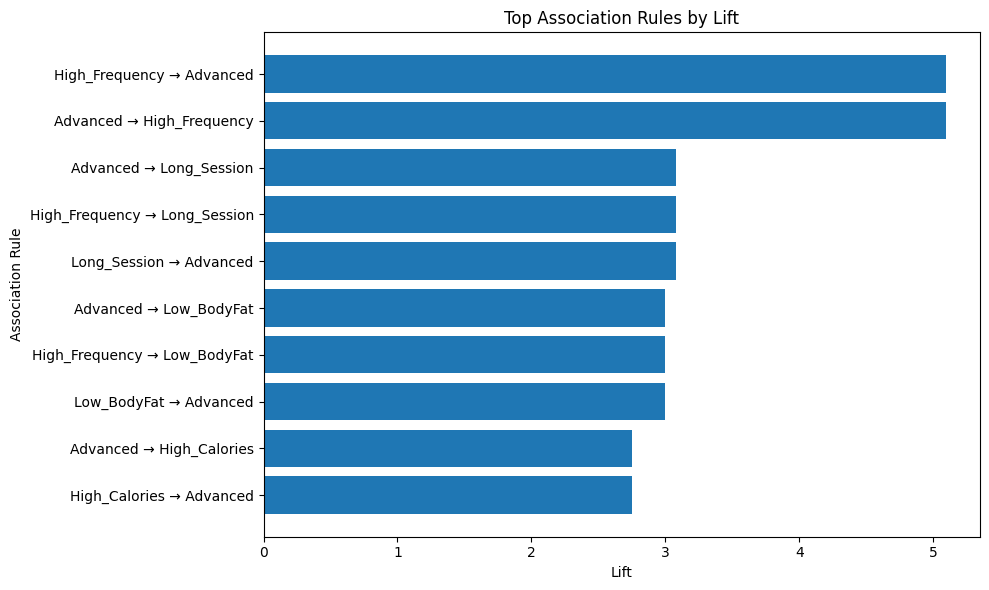

In [211]:
# Select the top 10 rules by lift
top_rules = simple_rules_display.head(10).copy()

top_rules["Rule"] = (
    top_rules["Antecedent"]
    + " → "
    + top_rules["Consequent"]
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_rules["Rule"],
    top_rules["Lift"]
)

plt.xlabel("Lift")
plt.ylabel("Association Rule")
plt.title("Top Association Rules by Lift")

plt.gca().invert_yaxis()
plt.tight_layout()

plt.show()

### **Interpretation of Association Rules**

The association rule analysis identified several strong relationships among workout frequency, experience level, session duration, calories burned, and body fat.

One of the strongest rules was **High_Frequency → Advanced**, with support of 0.105, confidence of 1.00, and lift of 5.09. This means approximately 10.5% of the dataset contained both characteristics, and every member categorized as having a high workout frequency was also categorized as advanced. The lift of 5.09 indicates that advanced experience was about five times more likely among high-frequency members than would be expected if the characteristics were independent.

The rule **Advanced → Long_Session** had support of 0.196, confidence of 1.00, and lift of 3.08. Therefore, all members categorized as advanced also belonged to the long-session category. Similarly, **Advanced → Low_BodyFat** had confidence of 1.00 and lift of 2.99, indicating a strong association between advanced experience and lower body-fat levels.

Another meaningful relationship was **Advanced → High_Calories**, which had support of 0.180, confidence of 0.916, and lift of 2.75. Approximately 91.6% of advanced members were in the high-calorie-burn category, suggesting that advanced members generally participated in workouts associated with greater energy expenditure.

Strong relationships were also found independently of experience level. The rule **Low_Calories → Short_Session** had confidence of 0.830 and lift of 2.47, while **Short_Session → Low_Calories** had confidence of 0.823 and the same lift. This indicates a strong relationship between shorter workout sessions and lower calorie expenditure.

Similarly, **Long_Session → High_Calories** had confidence of 0.756 and lift of 2.27, showing that longer sessions were associated with greater calorie expenditure. Finally, **Long_Session → Low_BodyFat** had confidence of 0.674 and lift of 2.02, suggesting that lower body-fat levels occurred more frequently among individuals performing longer workout sessions.

Overall, the association rules reveal a consistent pattern in the dataset: advanced and high-frequency gym members tend to participate in longer sessions, burn more calories, and have lower body-fat levels, while shorter sessions are strongly associated with lower calorie expenditure. These relationships represent associations within the dataset and should not be interpreted as causal relationships.

## **Association Rule Visualization**

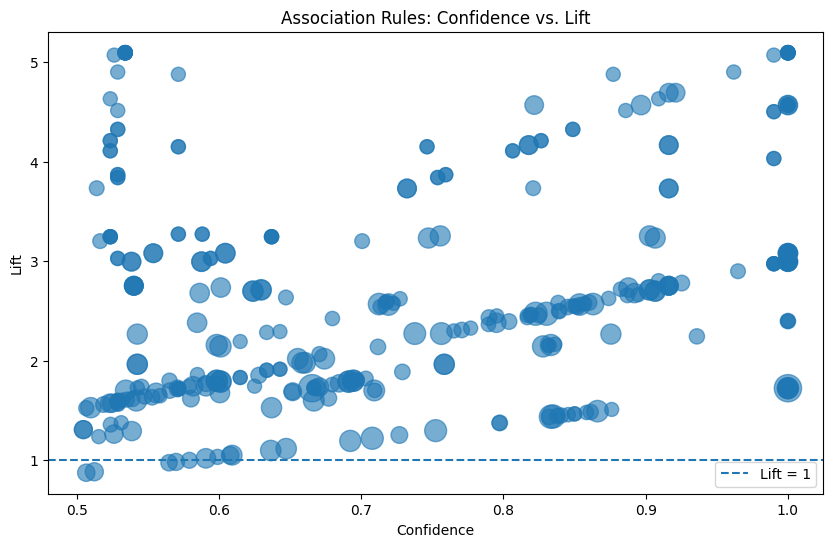

In [212]:
plt.figure(figsize=(10, 6))

plt.scatter(
    rules["confidence"],
    rules["lift"],
    s=rules["support"] * 1000,
    alpha=0.6
)

plt.xlabel("Confidence")
plt.ylabel("Lift")
plt.title("Association Rules: Confidence vs. Lift")

plt.axhline(y=1, linestyle="--", label="Lift = 1")
plt.legend()

plt.show()

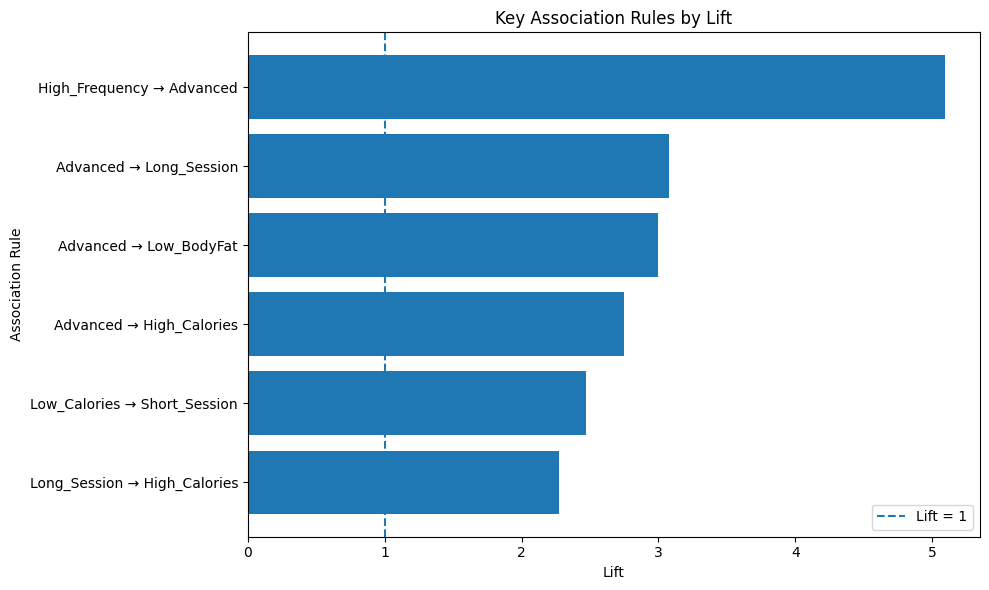

In [213]:
# Select representative, non-redundant association rules
representative_rule_names = [
    ("High_Frequency", "Advanced"),
    ("Advanced", "Long_Session"),
    ("Advanced", "Low_BodyFat"),
    ("Advanced", "High_Calories"),
    ("Low_Calories", "Short_Session"),
    ("Long_Session", "High_Calories")
]

representative_rules = simple_rules_display[
    simple_rules_display.apply(
        lambda row: (row["Antecedent"], row["Consequent"])
        in representative_rule_names,
        axis=1
    )
].copy()

representative_rules["Rule"] = (
    representative_rules["Antecedent"]
    + " → "
    + representative_rules["Consequent"]
)

representative_rules = representative_rules.sort_values("Lift")

plt.figure(figsize=(10, 6))

plt.barh(
    representative_rules["Rule"],
    representative_rules["Lift"]
)

plt.xlabel("Lift")
plt.ylabel("Association Rule")
plt.title("Key Association Rules by Lift")
plt.axvline(x=1, linestyle="--", label="Lift = 1")
plt.legend()

plt.tight_layout()
plt.show()

## **Overall Classification Findings**

The classification analysis showed that predicting a gym member's workout type from the available demographic, physiological, and exercise-related variables was difficult.

- The baseline Decision Tree achieved an accuracy of approximately **26.15%** and a weighted F1 score of **25.97%**.
- The k-NN classifier achieved a lower accuracy of approximately **23.08%** and a weighted F1 score of **22.99%**.
- The Decision Tree therefore performed slightly better than k-NN, although both models demonstrated weak predictive performance.
- ROC-AUC values were generally close to **0.50**, indicating limited ability to distinguish between Cardio, HIIT, Strength, and Yoga.
- Hyperparameter tuning did not improve the Decision Tree. Test accuracy decreased to approximately **21.03%** and weighted F1 to **21.25%**.
- These results suggest that variables such as age, BMI, heart rate, workout duration, and body composition do not provide enough information to reliably determine a member's workout type.

Overall, workout type appears to have substantial overlap across the measured characteristics, suggesting that additional behavioral or preference-related features may be needed for accurate classification.

## **Overall Clustering Findings**

K-Means clustering was used to identify naturally occurring groups of gym members based on their physiological and workout-related characteristics.

- The silhouette analysis identified **k = 2** as the best-performing solution, with a silhouette score of approximately **0.231**.
- The resulting clusters were unequal in size, with **198 members in Cluster 0** and **775 members in Cluster 1**.
- Cluster 0 represented a smaller group of more experienced and active gym members. These members had longer workout sessions, higher workout frequency, greater calorie expenditure, higher water intake, and substantially lower body-fat percentages.
- Cluster 1 represented the majority of members and was characterized by shorter workout sessions, lower workout frequency, lower experience levels, lower calorie expenditure, and higher body-fat percentages.
- Age, weight, BMI, and heart-rate measurements were relatively similar between the two clusters, suggesting that these variables contributed less to the practical differences between the groups.
- The PCA visualization showed some separation between the clusters, although the first two principal components explained only approximately **48.16%** of the total variance.

Overall, the clustering results suggest that gym members are differentiated more strongly by **exercise behavior, experience, and body composition** than by basic demographic or cardiovascular characteristics. However, the relatively low silhouette score indicates that the clusters are not strongly separated and should be interpreted as broad behavioral profiles rather than completely distinct groups.

## **Overall Association Rule Findings**

Association rule mining revealed several strong relationships among workout frequency, experience level, session duration, calorie expenditure, and body composition.

- **High workout frequency → Advanced experience** was the strongest representative rule, with a confidence of **1.00** and lift of approximately **5.09**.
- Advanced members were strongly associated with **long workout sessions** (lift ≈ **3.08**) and **low body fat** (lift ≈ **2.99**).
- Advanced experience was also associated with **high calorie expenditure**, with confidence of approximately **0.92** and lift of **2.75**.
- **Short workout sessions and low calorie expenditure** were strongly associated, with a lift of approximately **2.47**.
- Similarly, **long workout sessions were associated with high calorie expenditure**, with a lift of approximately **2.27**.
- The confidence-versus-lift visualization showed that many generated rules had lift values greater than 1, indicating positive associations beyond what would be expected if the characteristics were independent.

Overall, the association rules suggest that workout frequency and experience level are closely related to exercise duration, calorie expenditure, and body composition. These relationships represent associations within the dataset and should not be interpreted as evidence of causation.

## **Final Key Insights**

The combined results from classification, clustering, and association rule mining provide several important insights into the gym-member dataset.

1. **Workout type is difficult to predict from the available features.**  
   Classification models performed close to the expected random baseline for a four-class problem. This suggests that demographic, physiological, and general workout measurements alone do not clearly distinguish whether a member performs Cardio, HIIT, Strength, or Yoga.

2. **Exercise behavior provides clearer structure than workout type.**  
   K-Means identified two broad member profiles primarily differentiated by workout frequency, session duration, experience level, calorie expenditure, water intake, and body-fat percentage.

3. **More experienced and frequent exercisers formed a distinct behavioral profile.**  
   The smaller cluster contained members who exercised more frequently, trained for longer periods, burned more calories, consumed more water, had greater experience, and had lower average body-fat percentages.

4. **Association mining reinforced the clustering findings.**  
   Strong rules connected high workout frequency with advanced experience and linked advanced experience with longer sessions, lower body fat, and higher calorie expenditure.

5. **Session duration was strongly related to calorie expenditure.**  
   Long sessions were positively associated with high calorie expenditure, while short sessions were strongly associated with low calorie expenditure.

6. **The dataset reveals stronger behavioral associations than predictive class boundaries.**  
   Although the classification models could not reliably predict workout type, clustering and association rule mining uncovered meaningful patterns among exercise habits, experience, and fitness characteristics.

Overall, the analysis suggests that workout frequency, session duration, and experience level are among the most informative characteristics for understanding differences among gym members. However, these findings describe patterns and associations within the dataset and should not be interpreted as causal relationships.

## **Practical Relevance and Recommendations**

The patterns identified through clustering and association rule mining have several potential practical applications in fitness and gym management.

1. **Member Segmentation and Personalized Programs**  
   The two clusters could be used as broad member profiles when designing fitness programs. Less experienced and moderately active members may benefit from programs focused on gradually increasing workout frequency and session duration, while more experienced members may require more advanced and individualized training programs.

2. **Member Engagement and Progression**  
   The strong association between workout frequency and experience level suggests that workout consistency is an important characteristic of advanced members in this dataset. Gyms could use workout frequency and experience information to identify different levels of member engagement and provide appropriate training resources.

3. **Workout Duration and Energy Expenditure**  
   Association rules showed that longer workout sessions were associated with higher calorie expenditure, while shorter sessions were associated with lower calorie expenditure. These patterns could help fitness professionals establish realistic expectations when discussing workout duration and energy expenditure with members.

4. **Data-Driven Member Profiling**  
   The clustering results indicate that exercise frequency, session duration, experience level, calorie expenditure, water intake, and body-fat percentage may be more useful for segmenting gym members than workout type alone. These characteristics could support more personalized fitness recommendations and member engagement strategies.

5. **Improving Future Predictive Models**  
   The weak classification results suggest that additional variables may be necessary to accurately predict workout preferences. Future datasets could include fitness goals, exercise preferences, injury history, training environment, motivation, and equipment availability to provide more informative predictors of workout type.

## **Limitations**

Several limitations should be considered when interpreting the results of this analysis.

- The classification models performed close to chance level, indicating that the available features were insufficient for reliably predicting workout type.
- The final K-Means model achieved a silhouette score of approximately 0.231, indicating considerable overlap between the two identified clusters.
- The first two PCA components explained approximately 48.16% of the total variance, meaning that the two-dimensional visualization does not represent all of the information used by the clustering model.
- Association rules identify co-occurrence rather than causal relationships. For example, the association between advanced experience and lower body fat does not demonstrate that experience itself causes lower body fat.
- Converting continuous variables into Low, Medium, and High categories improves the interpretability of association rules but also reduces numerical detail and can influence which patterns are discovered.
- Some extremely strong association rules may reflect structural relationships within this particular dataset and should not automatically be generalized to the broader gym-going population.

Future analysis could use larger and more diverse datasets, additional behavioral variables, alternative classification targets, and external validation to determine whether these patterns generalize beyond the current dataset.

## Overall Conclusion

This project demonstrated how multiple data mining techniques can be used together to better understand gym members' exercise and fitness data. EDA identified important patterns and relationships within the dataset, while regression examined the prediction of continuous outcomes and classification evaluated categorical predictions. Clustering revealed natural groupings among gym members, and association rule mining identified recurring relationships between workout and fitness characteristics.

Overall, the results showed that each technique provided a different perspective on the dataset, while also revealing limitations in predicting complex fitness outcomes from the available variables. The findings should therefore be interpreted as patterns and associations rather than causal relationships. Combining these methods provided a more complete understanding of the data and demonstrated the value of an end-to-end data mining workflow.
